<a href="https://colab.research.google.com/github/koffifidelek59-collab/agricultural-monitoring-ftw/blob/main/Tracking_Emissions_from_ML_Models_(Revised).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Reducing Your Climate Impact When Training Machine Learning Models

Author(s):
* Melanie Hanna (mdriscollhanna@gmail.com)
* Andres Felipe Perez Murcia (perezmaf@myumanitoba.ca)

Welcome to CCAI's tutorial on tracking and mitigating the emissions from ML model training!

In order to make edits to this notebook, you should press **File > "Save a Copy in Drive"**. This will ensure that any edits will be on your local copy, and they will not affect the notebook shared with everyone else.

---
### 📌 Submission note

**Author of this submission:** Fidele Koffi, WASCAL IMP-EGH (Energy and Green
Hydrogen Technology, System Analysis), Abdou Moumouni University, Niamey.
**Tutorial:** Hanna & Perez Murcia (2026), *Reducing Your Climate Impact When
Training Machine Learning Models*. MIT License.

All five exercises are completed. The tutorial's own cells, including its
reference solutions, are unchanged. My work is in the filled code cells and in
the markdown cells marked **✍️**, each placed immediately after the exercise it
answers and before the provided solution.

| Exercise | What I added beyond filling the blank |
|---|---|
| 1. Reduce the CNN | Why the saving is smaller than a parameter count would predict: energy tracks operations executed, not weights stored |
| 2. Early stopping | Why it is the best trade in the notebook (it removes waste, not capacity), and a note that the stopping criterion uses the test set |
| 3. Median pruner | The failure mode aggressive pruning carries, and how `n_startup_trials` controls it |
| 4. Embodied carbon | Computed from `emissions.csv` rather than by hand, plus a sensitivity analysis over utilisation, lifetime and manufacturing footprint |
| 5. Model card | Three fields the template lacks: emissions scope, deployment budget, and water |

**Plus one extension, and it is the part I would point a reader to first.** The
notebook measures training emissions and inference emissions separately and
never combines them. A deployed model pays training on every retrain and
inference on every call, so the comparison that decides which model to ship is

C_total = N_retrain x C_train + N_inference x C_inference + C_embodied

The section **Extension: the comparison that decides which model to deploy**
computes this from measurements already taken above. The conclusion "linear
regression is the clear environmental winner" turns out to be a statement about
one training run and zero forecasts, which is the research prototype's
situation and not a deployed system's.

**One correction worth flagging.** The embodied allocation formula divides job
time by four years of wall-clock hours, which assumes the GPU does useful work
every hour of its life. At a realistic utilisation the embodied share roughly
doubles. My Exercise 4 cell reports the range rather than a point value.

---


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/climatechange-ai-tutorials/tracking-ml-emissions/blob/main/Tracking_Emissions_from_ML_Models_(Revised).ipynb)

# Table of Contents


*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Target Audience](#target-audience)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Carbon Emissions Estimation Framework](#estimation-framework)
*   [Tracking Operational Emissions with CodeCarbon](#tracking-emissions)
*   [Operational Carbon Emissions Estimation](#operational-emissions)
*   [Embodied Carbon Emissions Estimation](#embodied-emissions)
*   [Model Cards and Datasheets for Datasets](#model-cards-and-datasheets)
*   [Water Usage](#water-usage)
*   [Results & Discussion](#results-and-discussion)
*   [References](#references)

<a name="overview"></a>

# Overview

This tutorial walks through the full lifecycle of estimating and
reducing the environmental footprint of training machine learning models, starting from measuring and reducing operational energy consumption to estimating embodied hardware emissions and reporting results transparently.

Specifically, you will learn how to:

- **Identify** the sources of carbon emissions from ML workloads, including both operational (electricity during training and inference) and embodied (hardware manufacturing) components.
- **Measure** a model's emissions using a package called CodeCarbon and understand the approximations involved in grid emissions-intensity estimation.
- **Reduce** emissions through practical strategies — algorithm selection, model simplification, early stopping, and pruned hyperparameter search — with quantified trade-offs against model performance.
- **Evaluate** hardware choices not just by speed and cost but by embodied carbon footprint, expected lifespan, and the hosting data center's energy grid and water usage profile.
- **Report** emissions transparently using structured formats such as Model Cards and Datasheets for Datasets, embedding carbon, water, and provenance metadata directly into ML documentation.

<a name="climate-impact"></a>

# Climate Impact

<!--
In this section, describe in more detail how the methods or tools introduced in this tutorial could have pathways to positive impact regarding climate change. The problem should be clearly explained and motivated for non-experts. Feel free to discuss relevant research works, real-world examples of successful applications, and/or climate startups or organizations that are making an impact using similar methods or tools to address climate-related challenges.

We also ask that authors emphasize the real-world impact of the methods, specifically: Who will be using the models? How will the models be used? What decisions will be made based on the outputs of these models? How will they impact existing systems/the environment/communities on the ground?
-->

Machine learning models can have a wide-ranging and potentially subtle impact on our climate. We categorize potential emissions from ML models into three broad levels:

* System-level
* Application-related
* Computing-related

This tutorial focuses on the computing-related impact of ML models — encompassing operational emissions, embodied hardware emissions, and water consumption — while providing context on the broader system-level and application-related dimensions.

<table style="text-align: center;">
<tr>
  <td>
   <img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41558-022-01377-7/MediaObjects/41558_2022_1377_Fig1_HTML.png"/>
  </td>
</tr>
<tr>
  <th>Framework for assessing the GHG emissions impacts of ML, Kaack et al. (2022) [1]</a></th>
</tr>
</table>

## System-level Impact

System-level impacts consider the societal implications of ML. These types of impacts may have the greatest potential for GHG emissions. For example, implementing a recommender system that increases the demand for physical goods also increases the emissions from the manufacture and eventual disposal of these products. Shifting to autonomous cars could reduce demand for public transit and simultaneously increase emissions, through the materials extraction, vehicle manufacturing, and vehicle operations.

## Application-related Impact

Application-related impacts consider _what_ a model will be used for in the wider context. For instance, does the model enable carbon emitters or hinder the expansion of renewable energy? Or alternatively, is it used for applications that enable emissions reductions or support the expansion of renewable energy?

On the negative side, for example, machine learning has been used to assist in identifying new oil fields for exploration [2]. AI has also helped to identify and track livestock in factory farms, an industry that accounts for about 9% of global GHG emissions [3]. Depending on the scenario, these application-related impacts can far exceed the emissions from hardware and computing.

Of course, ML can also be used to _reduce_ greenhouse gas emissions. For some hands-on examples of these types of situations, check out [CCAI’s other tutorials](https://www.climatechange.ai/tutorials?).

## Computing-related Impact

The computing-related climate impact of ML models extends beyond the
electricity consumed during training. It encompasses two distinct
components:

- **Operational emissions** — the electricity consumed during data
  processing, model training, and model inference, whose magnitude
  depends on hardware power draw, training duration, and the carbon
  intensity of the hosting energy grid.

- **Embodied emissions** — the carbon cost of manufacturing the
  hardware itself, from raw material extraction through assembly
  and transport, which must be amortized over the device's expected
  lifespan.

A complete environmental accounting also requires considering
**water consumption**, since data centers rely on freshwater for
server cooling and thermoelectric power generation — a footprint
that varies dramatically by region and cooling technology.

<table style="text-align: center;" width="50%">
<tr>
  <td>
   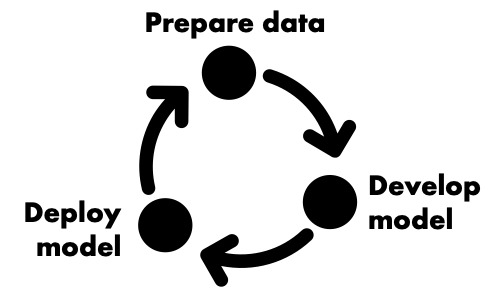
  </td>
</tr>
<tr>
  <th>The ML Lifecycle</a></th>
</tr>
</table>

While it's difficult to estimate the overall computing-related emissions attributed to ML, the field of Information and Communications Technology (ICT) currently accounts for roughly 1.8–2.8% of global GHG emissions, rising to an estimated 2.1–3.9% when omitted supply-chain pathways are accounted for [16]. This footprint is expected to remain under pressure from growing demand for data processing and computation, particularly from AI [16]. Roughly 30% of ICT's supply-chain-adjusted emissions are embodied emissions, while this share rises to about 50% for user devices such as smartphones [16].

### Case study: Large Language Models

While ICT's contribution to global emissions may seem small, the amount of compute needed to achieve state-of-the-art ML performance has grown rapidly [4]. These energy increases could be offset by hardware and algorithmic improvements [5]. But given the continued development of ever-larger models — from GPT-3 to the latest frontier models — we should remain vigilant in tracking and reducing the emissions associated with machine learning.

With that in mind, let's take a closer look at the emissions involved with both training and using these models!

Training GPT-3, the model underlying early versions of ChatGPT, consumed an estimated 1,287 MWh [5]. To put this number in perspective, the average annual electricity consumption for an American in 2021 was 10,632 kWh [10]. That means the energy used to train GPT-3 was the equivalent of adding 121 additional Americans to the grid for one year.

But we only realize value from these models when they are used at scale. For widely deployed models, inference can quickly overtake training as the dominant source of energy use, since models are typically used for far longer than they are trained. Precisely how much energy a query consumes changes as models and hardware evolve, so rather than pinning down a number that will soon be outdated, we recommend checking continuously maintained sources for current figures, such as [Epoch AI's analysis of ChatGPT's energy use](https://epoch.ai/gradient-updates/how-much-energy-does-chatgpt-use) and Hugging Face's [AI Energy Score leaderboard](https://huggingface.co/spaces/AIEnergyScore/Leaderboard), which benchmarks the per-query energy of current models.

As you integrate machine learning into your own research, you will likely train models that are far smaller than the newest GPT. But that doesn't mean that your work won't have a climate impact. Training a useful model requires a lot of experimentation, and the energy consumed by all those iterations can add up.

To reduce emissions from machine learning, we must first track them! Even if you're unable to apply any of the suggested strategies from this tutorial to minimize your impact, simply logging and reporting the associated emissions from your ML project is an important step.

Let's learn how we can calculate these emissions in the next section.

<a name="target-audience"></a>
# Target Audience
This tutorial is intended for experienced and aspiring data scientists looking for concrete examples of how to track carbon emissions while executing code and how to train machine learning models in a more efficient way. The reader should understand the basic mechanics of training an ML model, such as splitting data between train and test sets and tuning hyperparameters.

<a name="background-and-prereqs"></a>

# Background & Prerequisites

<!--
You will need to specify the prerequisites and basic knowledge required for the tutorial. Afterwards, please provide a brief explanation of the most important concepts necessary for the users to follow the tutorial.
-->

To get the most out of this tutorial, participants should have:

* Basic Python programming skills (variables, loops, functions, and libraries such as `numpy` and `pandas`).  
* Familiarity with Jupyter notebooks as an interactive environment for running code and exploring data.  
* A general understanding of Machine Learning (e.g., training and evaluating models) and Greenhouse gas (GHG) emissions.

To successfully follow the tutorial, users should be comfortable with the following concepts:

* What is kg CO2e? It stands for kilograms of carbon dioxide equivalent. It is the standard unit of measurement used in carbon accounting to express the total global warming impact of all different GHG emissions combined into a single, comparable number.
* The terms *productionalizing*, *operationalizing*, or *deploying* a model all refer to the process of providing the model for other users to make predictions.
* The term *model inference* is the stage of the machine learning lifecycle when we make predictions, which is also referred to as scoring new data.

<a name="software-requirements"></a>

# Software Requirements

This notebook requires Python (>= 3.9 and < 3.13) and an environment to run Jupyter notebooks with access to a GPU.

Fortunately, Google Colab provides free access to computing resources including GPUs. The GPUs currently available in Colab include the NVIDIA T4 (Turing) at the free tier along with updated paid tier configurations like the NVIDIA L4 (Ada Lovelace), NVIDIA A100s (Ampere), G4 (Blackwell), NVIDIA H100 (Hopper), and Google TPU v5e-1 and v6e-1. Review the official [Google Colab FAQ Resource Limits](https://research.google.com/colaboratory/faq.html#gpu-availability) section for further details on how hardware availability varies.

To enable GPU in Google Colab:
1. Navigate to Runtime → Change runtime type.
2. Select T4 GPU from the Hardware accelerator drop-down menu.
3. Click Save.

You can confirm your notebook is actively using the GPU hardware by running the following command inside any code cell:

In [2]:
%%bash
nvidia-smi

Mon Aug 24 15:42:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Other options are connecting [Google Colab to a local runtime](https://research.google.com/colaboratory/local-runtimes.html) or running the notebok on a shared cluster such as [High-Performance Computing (HPC)](https://en.wikipedia.org/wiki/TOP500) but we are not covering those in this tutorial.

All package requirements necessary to run this notebook can be installed through `pip` by running:

In [3]:
%%bash
wget -q https://raw.githubusercontent.com/afperezm/tracking-ml-emissions/develop/requirements.txt
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.6/220.6 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 132.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Now that the required dependencies have been installed we can import them:

In [4]:
%matplotlib inline
import os
import random

import numpy as np
import optuna
import pandas as pd
import scipy.stats
import sklearn
import sklearn.ensemble
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import xarray as xr
from codecarbon import EmissionsTracker

try:
    from google.colab.output import eval_js
except ImportError:
    # Define a dummy function that accepts any arguments and does nothing
    def eval_js(*args, **kwargs):
        pass

from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# Set seeds for reproducibility
# Per PyTorch, results may not be reproducible between CPU and GPU executions,
# even when using identical seeds
random.seed(0)
torch.manual_seed(0)
np.random.seed(0)

We will also create the structure of directories:

In [5]:
os.makedirs('./data', exist_ok=True)
os.makedirs('./models', exist_ok=True)
os.makedirs('./code_carbon', exist_ok=True)

<a name="data-description"></a>

# Data Description

<!--
In this section, kindly provide a brief description of the dataset that you will use in this tutorial. Specify information such as the data type or file format (e.g. text, image, video, tabular), size, spatial resolution, temporal resolution, labels or categories, etc.

If you are introducing a new dataset, please provide a [datasheet](https://arxiv.org/abs/1803.09010) alongside your tutorial submission that documents information about the creation, use, and limitations of your dataset. Please also summarize some of that information here and/or provide external links and resources that discuss the specific details of the dataset.
-->

<!--
We'll use the same data as the [Forecasting the El Nino / Southern Oscillation with Machine Learning tutorial](https://colab.research.google.com/github/climatechange-ai-tutorials/seasonal-forecasting/blob/main/CCAI_Seasonal_Forecasting_with_Exercises.ipynb) from earlier in the Summer School program. Remember that the goal of that tutorial was to leverage historical sea surface temperatures to correctly forecast the Nino3.4 index, which indicates the state of El Nino / Southern Oscillation (ENSO).
--->

This tutorial builds on the dataset from the  [Forecasting the El Nino / Southern Oscillation with Machine Learning tutorial](https://colab.research.google.com/github/climatechange-ai-tutorials/seasonal-forecasting/blob/main/CCAI_Seasonal_Forecasting_with_Exercises.ipynb), combining two climate datasets to predict the El Niño/Southern Oscillation (ENSO).

* The first dataset is the [COBE Sea-Surface Temperature (SST)](https://psl.noaa.gov/data/gridded/data.cobe.html), a historical global SST product developed by the Japan Meteorological Agency (JMA). COBE SST combines historical ship observations, ICOADS (International Comprehensive Ocean-Atmosphere Data Set) data, and modern buoys data into a gridded, interpolated product at 1 &deg; &times; 1 &deg; spatial resolution and monthly temporal resolution, spanning from 1880 to 2018.

* The second dataset is the [Niño 3.4 index](https://www.ncdc.noaa.gov/teleconnections/enso/indicators/sst/), provided by NOAA (National Oceanic and Atmospheric Administration). This index measures the 3-month rolling average of SST anomalies in the equatorial Pacific (5°N–5°S, 170°W–120°W) and serves as the primary indicator for El Niño and La Niña events. It is provided as monthly values in a text file, covering 1870 to the present.

## Data Download

Both datasets have been stored on a Google Drive shared storage space. They can be downloaded using [gdown](https://github.com/wkentaro/gdown) a lightweight open-source command-line tool by running:

In [6]:
# Download Nino3.4 index which measures the state of ENSO by encoding the
# average temperature anomaly in the equatorial Pacific
!gdown --output ./data/ --continue 1aGvitA8rYrHRDxNd2XD4AAFsahCQsv0t

Downloading...
From: https://drive.google.com/uc?id=1aGvitA8rYrHRDxNd2XD4AAFsahCQsv0t
To: /content/data/nino34.long.anom.data.txt
100% 15.4k/15.4k [00:00<00:00, 56.8MB/s]


In [7]:
# Download SST observations from 1880 to 2018
!gdown --output ./data/ --continue 1-xefk3imP4Q-8GevIV2YIo82iP5rTdSc

Downloading...
From (original): https://drive.google.com/uc?id=1-xefk3imP4Q-8GevIV2YIo82iP5rTdSc
From (redirected): https://drive.google.com/uc?id=1-xefk3imP4Q-8GevIV2YIo82iP5rTdSc&confirm=t&uuid=92ee4164-ac0d-47b9-9542-6e20bef73664
To: /content/data/sst.mon.mean.trefadj.anom.1880to2018.nc
100% 432M/432M [00:02<00:00, 167MB/s]


## Data Preprocessing

<!--
Additionally, you can include any data preprocessing steps and exploratory data analyses (e.g. visualize data distributions, impute missing values, etc.) in this section to allow the users to better understand the dataset. Visualizations should accurately reflect the data and support the central idea of the tutorial while looking professional. For suggestions on good data visualizations please see [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/).

In this section, you might also want to describe the different input and output variables, the train/val/test splits, and any data transformations.

```python
# Insert data pre-processing and exploratory data analysis
# code here. Feel free to break this up into several code
# cells, interleaved with explanatory text.
```
-->

The task consists of using historical SST fields to predict the Niño 3.4 index at lead times ranging from 1 to 5 months. The input variable is global SST (in Kelvin), provided as monthly anomaly fields in NetCDF format. The Niño 3.4 index is the target (output) variable for our prediction task, representing the state of ENSO at a given lead time.

In [8]:
def load_enso_indices():
    """
    Reads in the txt data file to output a pandas Series of ENSO vals

    Returns:
      pd.Series: monthly ENSO values starting from 1870-01-01
    """
    with open("data/nino34.long.anom.data.txt") as f:
        line = f.readline()
        enso_vals = []
        while line:
            yearly_enso_vals = map(float, line.split()[1:])
            enso_vals.extend(yearly_enso_vals)
            line = f.readline()

    enso_vals = pd.Series(enso_vals)
    enso_vals.index = pd.date_range("1870-01-01", freq="MS", periods=len(enso_vals))
    enso_vals.index = pd.to_datetime(enso_vals.index)
    return enso_vals


def assemble_basic_predictors_predictands(start_date, end_date, lead_time):
    """
    Creates a tuple of the predictors (np array of sst temperature anomalies)
    and the predictands (np array the ENSO index at the specified lead time).

    Parameters:
        start_date (str): the start date from which to extract sst
        end_date (str): the end date
        lead_time (str): the number of months between each sst
            value and the target Nino3.4 Index

    Returns:
        (np.array, np.array)

    """
    ds = xr.open_dataset("data/sst.mon.mean.trefadj.anom.1880to2018.nc")
    sst = ds["sst"].sel(time=slice(start_date, end_date))
    num_time_steps = sst.shape[0]

    # sst is a 3D array: (time_steps, lat, lon)
    # in this tutorial, we will not be using ML models that take
    # advantage of the spatial nature of global temperature
    # therefore, we reshape sst into a 2D array: (time_steps, lat*lon)
    # (At each time step, there are lat*lon predictors)
    sst = sst.values.reshape(num_time_steps, -1)
    sst[np.isnan(sst)] = 0

    X = sst

    start_date_plus_lead = pd.to_datetime(start_date) + pd.DateOffset(months=lead_time)
    end_date_plus_lead = pd.to_datetime(end_date) + pd.DateOffset(months=lead_time)
    y = load_enso_indices()[slice(start_date_plus_lead, end_date_plus_lead)]

    ds.close()
    return X, y

The data is split as as follows:
* Training is performed on SST observations and corresponding Niño 3.4 indices from 1980 to 1995
* Validation is conducted on data from 1997 to 2006
* Testing is carried out on data from 2007 to 2017.

<!--
SST values are reshaped from 3D arrays of shape (time, lat, lon) into 2D arrays of shape (time, lat × lon) for non-spatial models, or kept as 4D arrays for CNNs, with missing values set to zero.
-->

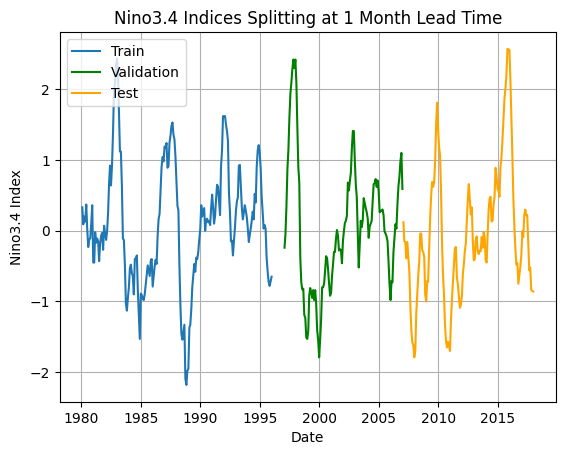

In [9]:
X_train, y_train = assemble_basic_predictors_predictands(
    "1980-01-01", "1995-12-31", lead_time=1
)
X_val, y_val = assemble_basic_predictors_predictands(
    "1997-01-01", "2006-12-31", lead_time=1
)
X_test, y_test = assemble_basic_predictors_predictands(
    "2007-01-01", "2017-12-31", lead_time=1
)

plt.plot(y_train.sort_index(), label="Train")
plt.plot(y_val.sort_index(), color='green', label="Validation")
plt.plot(y_test.sort_index(), color='orange', label="Test")

plt.legend(loc="best")
plt.title("Nino3.4 Indices Splitting at 1 Month Lead Time")
plt.ylabel("Nino3.4 Index")
plt.xlabel("Date")

plt.grid(True)
plt.show()
plt.close()

<a name="estimation-framework"></a>

# Carbon Emissions Estimation Framework

In this tutorial we follow the framework of Luccioni et al. (2023) [12] where the carbon footprint of training a machine learning model is divided into three sources of emissions:

* **Embodied emissions:** Arise from the production of the hardware used for training, including the extraction of raw materials, manufacturing, transportation, and disposal of GPUs and servers

* **Dynamic consumption emissions:** Correspond to the electricity consumed while the hardware is actively training the model.

* **Idle consumption emissions:** Correspond to the additional electricity required to operate the surrounding data center infrastructure, such as cooling, networking, and other supporting systems.

<table style="text-align: center;" width="100%">
<tr>
  <td>
    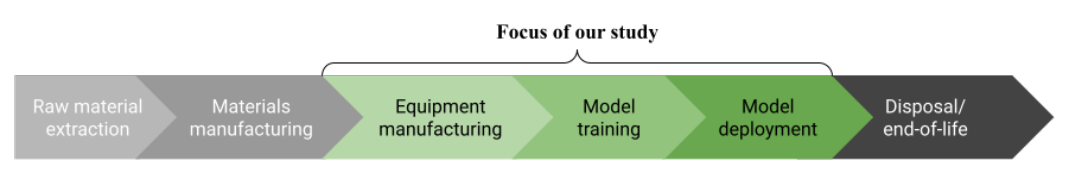
  </td>
</tr>
<tr>
  <th>Product life cycle stages under the Life Cycle Assessment (LCA) framework, highlighting the specific scope examined in Luccioni et al. (2023) [12]</a></th>
</tr>
</table>

For practical purposes, these three sources are grouped into two quantities: 1) Operational carbon emissions combining the emissions from dynamic and idle electricity consumption, and 2) Embodied carbon emissions corresponding to the emissions associated with manufacturing the hardware.

Consequently, the total carbon footprint can be expressed as:

$$
C_{total} = C_{operational} + C_{embodied}
$$

<!-- where Operational Carbon = Dynamic Consumption + Idle Consumption, and Embodied Carbon = Embodied Emissions. -->

where the operational carbon is given by

$$
C_{operational​} = C_{dynamic​}+C_{idle​}=EI,
$$

with $E$ denoting the electrical energy consumed during training (kWh) and $I$ denoting the carbon intensity of the electricity grid (kgCO<sub>2</sub>eq/kWh). When direct measurements of energy consumption are unavailable, $E$ is commonly approximated as the product of the average hardware power consumption $P$ (kW) and the training time $T$ (h), yielding

$$
C_{operational}​ ~≈ PTI.
$$

To reduce the emissions impact of a training an ML model, we can either reduce the amount of electricity required or shift our compute to an energy grid with a lower carbon intensity and footprint. In the upcoming sections we will study how to measure both sources of emissions, what strategies can we adopt to tackle them, and how to effectively report these measurements.

## Measuring Power Usage

Understanding how hardware consumes power is essential for
estimating a model's carbon footprint, since emissions are
directly proportional to the energy each component draws during
training.

At the heart of any computer is the **CPU** (Central Processing
Unit), which handles general-purpose computation. CPUs contain
only a handful of cores, so they execute tasks sequentially — one
operation after another. This makes them well-suited for logic
and control flow but inefficient for the large-scale matrix
operations that dominate neural network training.

**GPUs** (Graphics Processing Units) were originally designed for
rendering images but have become the workhorses of machine
learning precisely because they pack thousands of cores into a
single chip. Each core can handle a small piece of a larger
computation simultaneously, a model known as _parallel processing_.
A task that might take a CPU minutes to complete sequentially can
finish in seconds when distributed across a GPU's cores.

Google's **TPUs** (Tensor Processing Units) take this further
with custom silicon designed specifically for the tensor
operations underlying deep learning frameworks like [TensorFlow](https://www.tensorflow.org/).

The component that ties these processors together is **RAM**
(Random Access Memory), which provides fast, temporary storage
for the data and model parameters that the CPU or GPU needs to
access quickly during computation.

## Hardware Power Consumption

Hardware power consumption is often measured in Thermal Design
Power (TDP), which represents the maximum amount of heat a
processor will generate under an intense workload. CPUs designed
for general-purpose computing typically have a TDP around 65 W (as reported in the [CodeCarbon internal reference database](https://github.com/mlco2/codecarbon/blob/master/codecarbon/data/hardware/cpu_power.csv)),
while GPUs built for parallel workloads often exceed 100 W.

Higher power draw does not necessarily translate to higher
emissions, because what matters is total energy consumed, i.e., power multiplied by time. A GPU consuming 150 W that finishes
training in one hour uses less total energy than a 65 W CPU
that takes ten hours to accomplish the same work. The net
effect on emissions depends on how quickly the hardware
completes the task relative to its power draw.

Research has found that this trade-off is not simply "more
cores is better." There is likely a specific optimal number
of cores for a given parallel computation that minimizes
emissions, as illustrated in the figure below [11]. Beyond
that point, adding more cores increases power consumption
faster than it reduces training time, pushing total emissions
back up.

<center><p><p> <img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*bFhKxp5JhjA_RQ_hIo1pHQ.png" alt="alt" width="60%"/></center>

<!--

<a name="methodology"></a>

# Methodology

In this section, describe a step-by-step walkthrough of the methodology, in the form of code cells. Feel free to make use of markdown headings to break this section up into smaller subsections, preferrably one section per task.

Reminders:
*   Split the code into small, digestible chunks.
*   Use text cells to describe each code block.
*   Avoid duplicate code through modularization.

Given the sequential nature of notebook cells, if any experiment requires users to rerun previous cells please provide clear and explicit instructions to do so.

If this section leverages trained machine learning models eated by you, please provide a [model card](https://arxiv.org/abs/1810.03993) alongside your tutorial submission that documents information about the creation, use and limitations of your machine learning model. You may find it helpful to use this [model card creation tool](https://huggingface.co/spaces/huggingface/Model_Cards_Writing_Tool). For existing trained models that you did not create, please do your best to link to an existing model card or other links/resources that provide important information about the model.

Please also use the [CodeCarbon library](https://codecarbon.io/) to instrument your code for energy and emissions tracking. See [this tutorial](https://www.climatechange.ai/tutorials?search=reducing+your+climate+impact+when+training+ML+models) for example usage of CodeCarbon within a Colab notebook.
-->

<a name="tracking-emissions"></a>

# Tracking Operational Emissions with CodeCarbon

<!--
A model’s carbon footprint from computing-related impacts can be estimated as the product of electricity consumed and the carbon intensity of that electricity. To reduce the climate impact of a model, we can either reduce the amount of electricity required or shift our compute to an energy grid with a lower carbon intensity. In the upcoming sections we will study how to measue both sources of emission and what strategies can we adopt to tackle them.
-->

A model's carbon footprint from computing-related impacts can be
estimated as the product of electricity consumed and the carbon
intensity of that electricity:

$$C_{operational} = E \times I$$

where $E$ is the electrical energy consumed during training (kWh) and $I$ is the carbon intensity of the electricity grid
(kgCO₂eq/kWh). To reduce the emissions impact of a model, we can
either reduce the amount of electricity required or shift our
compute to an energy grid with a lower carbon intensity.

In this section, we will use CodeCarbon to measure both terms
and then explore practical strategies to reduce them.

## Introducing CodeCarbon

To measure the computing-related carbon footprint of ML training, we'll use a Python package called [CodeCarbon](https://github.com/mlco2/codecarbon), developed by
teams at [Mila - Quebec AI Institute](https://mila.quebec/en/), [BCG Gamma](https://www.bcg.com/beyond-consulting/bcg-gamma/overview), [Haverford College](https://www.haverford.edu/), and
[Comet](https://www.comet.com/site/).

CodeCarbon estimates emissions by combining two measurements:

- **Energy consumed** ($E$): CodeCarbon profiles the electricity
  usage of the GPU, CPU, and RAM involved in your code by polling hardware power draw at regular intervals (default: every 15 seconds).

- **Carbon intensity** ($I$): CodeCarbon looks up the carbon
  intensity of the energy grid serving your compute, using
  per-country or per-cloud-provider data when available, and a
  global average of 475 g CO₂eq/kWh as a fallback.

<center><p><p> <img src="https://raw.githubusercontent.com/mlco2/codecarbon/refs/heads/master/docs/images/calculation.png" alt="alt" width="75%"/></center>

Several other packages provide similar functionality —
[carbontracker](https://github.com/lfwa/carbontracker),
[experiment-impact-tracker](https://github.com/Breakend/experiment-impact-tracker), and [eco2ai](https://github.com/sb-ai-lab/Eco2AI) — but CodeCarbon is the most actively maintained. For a comparison of these tools, see Table 1 in [6].

## Measuring Energy Consumption

CodeCarbon measures the electricity consumption of the GPU, CPU, and RAM used for executing your code. These measurements are taken at regular time intervals, with a default setting of 15 seconds. Note that [TPU support](https://github.com/mlco2/codecarbon/issues/116) may be limited due to the difficulty of obtaining live power usage for this type of hardware; check the [CodeCarbon documentation](https://docs.codecarbon.io/latest/) for current hardware compatibility.

Let's start the tracker and see what hardware CodeCarbon detects.

In [10]:
# Instantiate the tracker object
tracker = EmissionsTracker(
    output_dir="./code_carbon/",  # define the directory to which we'll write our emissions results
    output_file="emissions.csv",  # define the name of the file containing our emissions results
    # log_level="error",  # comment out this line to see regular output
)

tracker.start()

[codecarbon WARNING @ 15:44:55] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:44:55] Emissions data (if any) will be saved to file /content/code_carbon/emissions.csv
[codecarbon INFO @ 15:44:55] [setup] RAM Tracking...
[codecarbon INFO @ 15:44:55] [setup] CPU Tracking...
[codecarbon INFO @ 15:44:55] [setup] GPU Tracking...
[codecarbon INFO @ 15:44:55] Tracking Nvidia GPUs via PyNVML
[codecarbon WARNING @ 15:44:57] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:44:57] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 15:44:57] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 15:44:57] CPU Model on constant consumption mode: Intel(R) Xeon(R) 

Aside from the explicit object approach, the tracker can also be instantiated using the more idiomatic context manager pattern or even a decorator. Check out the [CodeCarbon documentation](https://docs.codecarbon.io/latest/tutorials/python-api/#tracking-with-python) for more information on these techniques.

The output from the tracker initialization reports the hardware
it found. Here is what was displayed when running this notebook on a Colab T4 instance:

```
[codecarbon WARNING @ 05:35:38] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 05:35:38] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 05:35:38] No CPU tracking mode found. Falling back on estimation based on TDP for CPU.
...
[codecarbon INFO @ 05:35:38]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.35
[codecarbon INFO @ 05:35:38]   Python version: 3.12.13
[codecarbon INFO @ 05:35:38]   CodeCarbon version: 3.2.9
[codecarbon INFO @ 05:35:38]   Available RAM : 12.671 GB
[codecarbon INFO @ 05:35:38]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 05:35:38]   CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon INFO @ 05:35:38]   GPU count: 1
[codecarbon INFO @ 05:35:38]   GPU model: 1 x Tesla T4
```

CodeCarbon estimated RAM power by applying a rule of thumb: each
8 GB of memory accounts for approximately 3 W, giving about 4.75 W for 12.681 GB. For the two CPUs, Colab does not expose enough information for CodeCarbon to measure actual power draw, so it falls back on a constant TDP of 85 W assumed to be 50% utilized, yielding 42.5 W.

Finally, for the GPU CodeCarbon has found one Nvidia Tesla T4 GPU. CodeCarbon leverages Nvidia's [`pynvml`](https://pypi.org/project/pynvml/) library to directly access the GPU's power rating.

In [11]:
# Note that CodeCarbon will output the energy consumption every time you execute code
# Comment out the `log_level` argument when instantiating the tracker to suppress this output
print("All hardware identified:", tracker._hardware)
print("GPU Power:", tracker._hardware[1].total_power())

All hardware identified: [RAM(), GPU() (Tesla T4), CPU(Cpu Load)]
GPU Power: Power(kW=0.013558730269363049)


## Measuring Carbon Intensity

Once CodeCarbon knows how much energy your code consumed, it
multiplies that by the carbon intensity of the electricity grid
to estimate emissions. CodeCarbon looks up grid intensity using a
priority hierarchy:

1. **Per-cloud-provider data** when running on a recognized cloud
   platform.
2. **Per-country data** when the country's carbon intensity is
   available.
3. **Electricity mix breakdown** if the country's overall
   intensity is unavailable but its energy source mix is known. CodeCarbon calculates a weighted average using per-source
   carbon intensities. Note that the same carbon intensity is
   assigned to a given energy source regardless of location (i.e.
   coal's intensity is treated the same in West Virginia and
   Germany).
4. **Global average** of 475 g CO<sub>2</sub>eq/kWh as a final fallback.

> **Important:** Given the simplifying assumptions above (static
> historical averages, no real-time grid data, no facility-level
> PUE) the emissions returned by CodeCarbon are approximations,
> not exact measurements.

## Colab Compute Region

Let's check which compute region Colab has assigned to this
session.

In [12]:
tracker._geo

Colab connected to Google's data center in Iowa for this session.
The region may change each time you restart your runtime, for
example, a user physically in Chicago might be routed to
Singapore.

CodeCarbon estimates Iowa's grid carbon intensity at roughly
453 kg CO<sub>2</sub>eq/kWh (converted from the 997.858 lbs CO<sub>2</sub>eq/MWh figure in its [2016 US regional dataset](https://github.com/mlco2/codecarbon/blob/master/codecarbon/data/private_infra/2016/usa_emissions.json)). CodeCarbon's US grid intensity data has not been updated since 2016, which means the values used here may not reflect recent shifts in Iowa's energy mix toward renewables. For more current regional intensity data, tools like
[Electricity Maps](https://app.electricitymap.org) can be
consulted independently.

Among US states in CodeCarbon's dataset, Iowa falls in the middle
of the range. Vermont (26 kg CO<sub>2</sub>eq/kWh) and Idaho (86 kg
CO<sub>2</sub>eq/kWh) represent the lowest-intensity options, while West
Virginia (896 kg CO<sub>2</sub>eq/kWh) is among the highest. On cloud
platforms such as AWS, GCP, or Azure, you can choose your compute
region explicitly, making this kind of optimization more
straightforward than on Colab.

## Stopping the Tracker

Stopping the tracker totals all the energy consumed since
initialization and multiplies by the grid's carbon intensity to
produce a final emissions estimate in CO<sub>2</sub>eq.

> **Note:** Your emissions will likely differ from any values
> shown in this tutorial, since Colab may assign different
> hardware and a different compute region each session.

In [13]:
emissions = tracker.stop()

print(f"Emissions from this training run: {emissions:5f} kg CO2eq")

[codecarbon INFO @ 15:46:02] Energy consumed for RAM : 0.000179 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:46:02] Energy consumed for all GPUs : 0.000243 kWh. Total GPU Power : 13.589740075094234 W
[codecarbon INFO @ 15:46:02] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 1.0609024688 W
[codecarbon INFO @ 15:46:02] Energy consumed for All CPU : 0.000019 kWh
[codecarbon INFO @ 15:46:02] 0.000442 kWh of electricity and 0.000000 L of water were used since the beginning.


Emissions from this training run: 0.000061 kg CO2eq


The tracker writes a detailed log to `code_carbon/emissions.csv`,
recording energy consumption per hardware component, the compute
region, and the carbon intensity used for the estimate.

These logged emissions can be visualized via CodeCarbon's dashboard which allows to breakdown of the emissions by hardware component. Even the brief initialization code in this section, which only profiles hardware and determines the compute region, produces measurable emissions, illustrating how even minor compute tasks carry a carbon cost.

This dashboard is hosted via a Dash app and in order to access it on Colab's servers, a proxy link is necessary.

> **Note:** after executing the cell below, click on the link next to the text stating "CLICK HERE" to access the Dashboard. Once you're done reviewing it, click on the cell's stop button.

In [14]:
## UNCOMMENT THIS CELL TO RUN THE CODECARBON DASHBOARD ##

# # Display the proxy link
# print("CLICK HERE:", eval_js("google.colab.kernel.proxyPort(8050)"), "\n")

# # Point to our emissions csv file
# !carbonboard --filepath="code_carbon/emissions.csv" --port=8050

Executing just a few cells of code to assess the underlying hardware and compute region resulted in carbon emissions equivalent to watching 7 minutes of a 32-inch LCD TV.

<a name="operational-emissions"></a>

# Operational Carbon Emissions Estimation

Let's try tracking our carbon emissions while training a machine learning model. We'll also explore a few techniques to train in a more efficient way and reduce our emissions.

## Generate Training and Test Data

We'll move quickly through this data preparation section as the focus of this tutorial is on model training and emissions tracking. For a more detailed walkthrough, please reference the original forecasting tutorial.

In [15]:
def plot_nino_time_series(y, predictions, title):
    """
    Plots the ENSO time series against the predictions.

    Parameters:
      y (pd.Series): time series of the true Nino index
      predictions (np.array): time series of the predicted Nino index (same
          length and time as y)
      title (str): the title of the plot

    Returns:
      (None): Displays the plot
    """
    predictions = pd.Series(predictions, index=y.index)
    predictions = predictions.sort_index()
    y = y.sort_index()

    plt.plot(y, label="Ground Truth")
    plt.plot(predictions, "--", label="ML Predictions")
    plt.legend(loc="best")
    plt.title(title)
    plt.ylabel("Nino3.4 Index")
    plt.xlabel("Date")
    plt.show()
    plt.close()

## Algorithm Choice

One of the easiest ways to reduce emissions is by choosing a simpler algorithm. We often don't need to immediately reach for a large or complicated neural network when a smaller or more traditional machine learning method would suffice.


<table style="text-align: center;" width="50%">
<tr>
  <td>
   <img src="https://external-preview.redd.it/khzQQ3xzswIW4HGIvesRWJXvCbnvdWNarIyU4-GVl2I.jpg?width=640&crop=smart&auto=webp&s=180b2912c6bef455fcb4ef7565dd5093edbabe23" width="100%">
  </td>
</tr>
<tr>
  <th>Applying a neural network when linear regression would do.</a></th>
</tr>
</table>

We'll discuss more about the potential trade-offs involved in choosing a simple algorithm over a more complicated one at the end of this section. For now, we'll focus on training two different models and capturing the emissions from each one.




### Training a Baseline Model: Linear Regression

Let's first attempt to model ENSO using linear regression. We'll track the emissions associated with training this simple model.

In [16]:
experiment_name = "linear_regression"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

[codecarbon WARNING @ 15:46:39] Multiple instances of codecarbon are allowed to run at the same time.


RMSE: 0.53


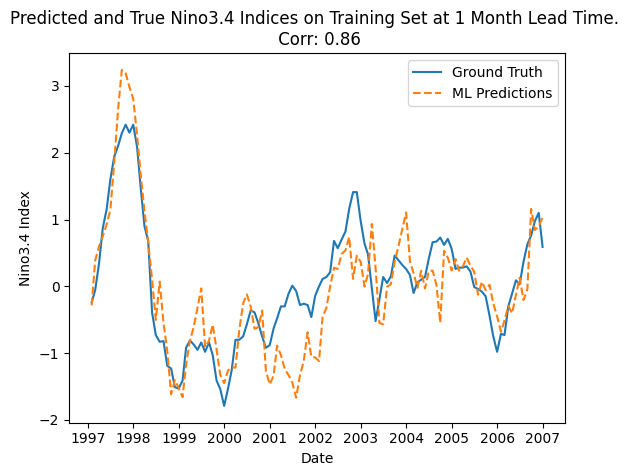

In [17]:
# Load train, val, and test sets
X_train, y_train = assemble_basic_predictors_predictands(
    "1980-01-01", "1995-12-31", lead_time=1
)
X_val, y_val = assemble_basic_predictors_predictands(
    "1997-01-01", "2006-12-31", lead_time=1
)
X_test, y_test = assemble_basic_predictors_predictands(
    "2007-01-01", "2017-12-31", lead_time=1
)

# Train a linear regression model
regr = sklearn.linear_model.LinearRegression()
regr.fit(X_train, y_train)

predictions = regr.predict(X_val)
corr, _ = scipy.stats.pearsonr(predictions, y_val)
baseline_rmse = root_mean_squared_error(y_val, predictions)
print("RMSE: {:.2f}".format(baseline_rmse))

# Plot predictions against actuals
plot_nino_time_series(
    y_val,
    predictions,
    "Predicted and True Nino3.4 Indices on Training Set at 1 Month Lead Time. \n Corr: {:.2f}".format(
        corr
    ),
)

In [18]:
# Evaluate emissions
baseline_emissions = tracker.stop()
print(f"Emissions from this training run: {baseline_emissions:.5f} kg CO2eq")

Emissions from this training run: 0.00002 kg CO2eq


### Training a CNN

Let's compare the emissions and performance of a linear regression model to a more complex convolutional neural network (CNN).

First, we'll define some necessary data wrangling code.

In [19]:
def assemble_predictors_predictands(start_date, end_date, lead_time,
                                    num_input_time_steps=1):
    """
    Creates a tuple of the predictors (np array of sst temperature anomalies)
    and the predictands (np array the ENSO index at the specified lead time).

    Parameters:
      start_date (str): the start date from which to extract sst
      end_date (str): the end date
      lead_time (int): the number of months between each sst value and the
          target Nino3.4 Index
      num_input_time_steps (int): the number of time steps to use for each
          predictor sample

    Returns:
      (np.array, np.array)

    """
    file_name = "sst.mon.mean.trefadj.anom.1880to2018.nc"
    variable_name = "sst"
    ds = xr.open_dataset(f"./data/{file_name}")
    sst = ds[variable_name].sel(time=slice(start_date, end_date))

    num_samples = sst.shape[0]
    # sst is a (num_samples, lat, lon) array
    # the line below converts it to (num_samples, num_input_time_steps, lat, lon)
    sst = np.stack(
        [
            sst.values[n - num_input_time_steps : n]
            for n in range(num_input_time_steps, num_samples + 1)
        ]
    )
    num_samples = sst.shape[0]
    sst[np.isnan(sst)] = 0
    X = sst

    start_date_plus_lead = pd.to_datetime(start_date) + pd.DateOffset(
        months=lead_time + num_input_time_steps - 1
    )
    end_date_plus_lead = pd.to_datetime(end_date) + pd.DateOffset(months=lead_time)
    y = load_enso_indices()[slice(start_date_plus_lead, end_date_plus_lead)]
    ds.close()
    return X.astype(np.float32), y.astype(np.float32)


class ENSODataset(Dataset):
    def __init__(self, predictors, predictands):
        self.predictors = predictors
        self.predictands = predictands
        assert (
            self.predictors.shape[0] == self.predictands.shape[0]
        ), "The number of predictors must equal the number of predictands!"

    def __len__(self):
        return self.predictors.shape[0]

    def __getitem__(self, idx):
        return self.predictors[idx], self.predictands.iloc[idx]

Now we'll define the architecture of our convolutional neural network.

In [20]:
class CNN(nn.Module):
    def __init__(self, num_input_time_steps=1, print_feature_dimension=False):
        """
        Constructs all the necessary attributes for the CNN class.

        Parameters:
          num_input_time_steps (int) : the number of input time steps in the predictor
          print_feature_dimension (bool) : whether or not to print out the dimension
              of the features extracted from the conv layers
        """
        super().__init__()
        self.conv1 = nn.Conv2d(num_input_time_steps, 6, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.print_layer = Print()

        # TIP: print out the dimension of the extracted features from
        # the conv layers for setting the dimension of the linear layer!
        # Using the print_layer, we find that the dimensions are
        # (batch_size, 16, 42, 87)
        self.fc1 = nn.Linear(16 * 42 * 87, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)
        self.print_feature_dimension = print_feature_dimension

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        if self.print_feature_dimension:
            x = self.print_layer(x)
        x = x.view(-1, 16 * 42 * 87)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


class Print(nn.Module):
    """
    This class prints out the size of the features
    """

    def forward(self, x):
        print(x.size())
        return x

Let's define a class to train our CNN.

In [21]:
class TrainCNN:
    def __init__(self, trainloader, testloader, net, criterion, optimizer):
        """
        Contains the necessary code for training a CNN.

        Parameters
          trainloader (torch.utils.data.DataLoader): PyTorch dataloader that loads the
              predictors and predictands for the train dataset
          testloader (torch.utils.data.DataLoader): PyTorch dataloader that loads the
              predictors and predictands for the test dataset
          net (nn.Module): Neural network architecture
          criterion (nn): Loss function (i.e. root mean squared error)
          optimizer (torch.optim): Optimizer to use update the neural network
              architecture to minimize the loss function
        """
        self.trainloader = trainloader
        self.testloader = testloader
        self.net = net
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.train_losses = []
        self.test_losses = []
        self.best_loss = np.inf

    def _calculate_loss(self, data):
        """
        Calculates the loss of the current model.

        Parameters:
          data (torch.Tensor): Predictors and predictands against which to
              calculate loss of the current model

        Returns:
            torch.Tensor
        """
        # Get a mini-batch of predictors and predictands
        batch_predictors, batch_predictands = data
        batch_predictands = batch_predictands.to(self.device)
        batch_predictors = batch_predictors.to(self.device)

        # Zero the parameter gradients
        self.optimizer.zero_grad()

        # Calculate the predictions of the current neural network
        predictions = self.net(batch_predictors).squeeze(1)

        # Quantify the quality of the predictions using a
        # loss function (aka criterion) that is differentiable
        loss = self.criterion(predictions, batch_predictands)
        return loss

    def _train(self):
        """
        Trains the CNN for one iteration.

        Returns:
            None: Appends the current training loss
        """
        running_loss = 0.0
        self.net.train()

        for i, data in enumerate(self.trainloader):
            loss = self._calculate_loss(data)

            # The backward pass: calculates the gradients of each weight
            # of the neural network with respect to the loss
            loss.backward()

            # The optimizer updates the weights of the neural network
            # based on the gradients calculated above and the choice
            # of optimization algorithm
            self.optimizer.step()
            running_loss += loss.item()

        self.train_losses.append(running_loss / len(self.trainloader))

    def _evaluate_epoch(self):
        """
        Evaluates the test loss at the current epoch and updates the best loss
        if current loss is less than the previous best loss.

        Return:
          None: Appends the current test loss
        """
        running_loss = 0.0
        self.net.eval()

        for i, data in enumerate(self.testloader):
            loss = self._calculate_loss(data)
            running_loss += loss.item()

        # Save the model weights that have the best performance!
        if running_loss < self.best_loss:
            self.best_loss = running_loss
            torch.save(self.net, "models/current_best_cnn.pt")

        self.test_losses.append(running_loss / len(self.testloader))

    def train_network(self, num_epochs=40, verbose=True):
        """
        Trains a neural network for a specified number of epochs.

        Parameters:
          num_epochs (int): Number of epochs for which to train the network
          verbose (bool): Whether or not to print the current train and test loss

        Returns:
          None
        """
        net = self.net.to(self.device)
        for epoch in range(num_epochs):
            self._train()
            self._evaluate_epoch()
            if verbose:
                print(
                    "train Set: Epoch {:02d}. loss: {:3f}".format(
                        epoch + 1, self.train_losses[-1]
                    )
                )
                print(
                    "test Set: Epoch {:02d}. loss: {:3f}".format(
                        epoch + 1, self.test_losses[-1]
                    )
                )

        self.net = torch.load("models/current_best_cnn.pt", weights_only=False)
        self.net.eval()
        self.net.to(self.device)

    def evaluate_best_model(self):
        """
        Makes predictions against the current best model.

        Returns:
          np.array: Predictions from the model
        """
        if self.best_loss == np.inf:
            raise Exception("The model has not yet been trained!")

        predictions = np.asarray([])
        for i, data in enumerate(self.testloader):
            batch_predictors, batch_predictands = data
            batch_predictands = batch_predictands.to(self.device)
            batch_predictors = batch_predictors.to(self.device)

            batch_predictions = self.net(batch_predictors).squeeze()
            # Edge case: if there is 1 item in the batch, batch_predictions becomes a float
            # not a Tensor. the if statement below converts it to a Tensor
            # so that it is compatible with np.concatenate
            if len(batch_predictions.size()) == 0:
                batch_predictions = torch.Tensor([batch_predictions])
            predictions = np.concatenate(
                [predictions, batch_predictions.detach().cpu().numpy()]
            )
        return predictions

Now we'll kick off a new CodeCarbon experiment to track emissions from training this simple CNN.

In [22]:
experiment_name = "cnn"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

In [23]:
# Assemble numpy arrays corresponding to predictors and predictands
train_start_date = "1960-01-01"
train_end_date = "2005-12-31"
num_input_time_steps = 1
lead_time = 1

train_predictors, train_predictands = assemble_predictors_predictands(
    train_start_date,
    train_end_date,
    lead_time,
    num_input_time_steps=num_input_time_steps,
)
test_predictors, test_predictands = assemble_predictors_predictands(
    "2007-01-01",
    "2017-12-31",
    lead_time,
    num_input_time_steps=num_input_time_steps,
)

# Convert the numpy ararys into ENSODataset, which is a subset of the
# torch.utils.data.Dataset class.  This class is compatible with
# the torch dataloader, which allows for data loading for a CNN
train_dataset = ENSODataset(train_predictors, train_predictands)
test_dataset = ENSODataset(test_predictors, test_predictands)

# Create a torch.utils.data.DataLoader from the ENSODatasets() created earlier!
trainloader = DataLoader(train_dataset, batch_size=10)
testloader = DataLoader(test_dataset, batch_size=10)

In [24]:
# Train the model
net = CNN(num_input_time_steps=num_input_time_steps)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
cnn_train_session = TrainCNN(
    trainloader, testloader, net, criterion=nn.MSELoss(), optimizer=optimizer
)
cnn_train_session.train_network()

# Evaluate predictions from the best performing model
predictions = cnn_train_session.evaluate_best_model()

train Set: Epoch 01. loss: 0.495984
test Set: Epoch 01. loss: 0.224990
train Set: Epoch 02. loss: 0.144434
test Set: Epoch 02. loss: 0.147177
train Set: Epoch 03. loss: 0.075182
test Set: Epoch 03. loss: 0.088367
train Set: Epoch 04. loss: 0.068119
test Set: Epoch 04. loss: 0.145524
train Set: Epoch 05. loss: 0.097362
test Set: Epoch 05. loss: 0.146802
train Set: Epoch 06. loss: 0.074477
test Set: Epoch 06. loss: 0.165560
train Set: Epoch 07. loss: 0.092736
test Set: Epoch 07. loss: 0.124061
train Set: Epoch 08. loss: 0.060078
test Set: Epoch 08. loss: 0.106147
train Set: Epoch 09. loss: 0.050188
test Set: Epoch 09. loss: 0.100857
train Set: Epoch 10. loss: 0.050079
test Set: Epoch 10. loss: 0.110199
train Set: Epoch 11. loss: 0.061706
test Set: Epoch 11. loss: 0.183805
train Set: Epoch 12. loss: 0.060453
test Set: Epoch 12. loss: 0.191232
train Set: Epoch 13. loss: 0.053443
test Set: Epoch 13. loss: 0.112780
train Set: Epoch 14. loss: 0.056448
test Set: Epoch 14. loss: 0.089527
train 

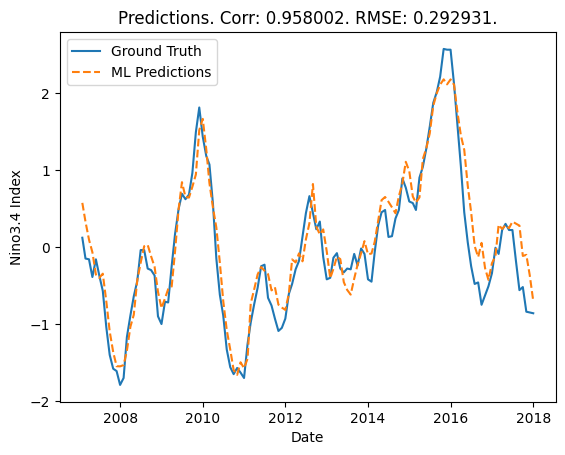

In [25]:
# Plot predictions against actuals over time
corr, _ = pearsonr(test_predictands, predictions)
cnn_rmse = root_mean_squared_error(test_predictands, predictions)
plot_nino_time_series(
    test_predictands,
    predictions,
    "Predictions. Corr: {:3f}. RMSE: {:3f}.".format(corr, cnn_rmse),
)

In [26]:
# Stopping the tracker will create a new file (emissions.csv) in our notebook's
# working directory with info on the emissions generated from this experiment
cnn_emissions = tracker.stop()
print(f"Emissions from this training run: {cnn_emissions:5f} kg CO2eq")

Emissions from this training run: 0.000098 kg CO2eq


### Comparing Emissions and Accuracy

Let's compare the emissions from training a linear regression model with those from training a CNN.

In [27]:
print(
    f"CNN emissions account for {cnn_emissions/baseline_emissions:.1f} times the emissions from linear regression."
)

CNN emissions account for 5.2 times the emissions from linear regression.


Wow! Linear regression is the clear environmental winner in terms of reducing carbon impact. Of course, we must also consider the performance of our model. How well does it forecast ENSO? Let's compare the root squared mean error (RMSE) from both models. Remember that a lower RMSE indicates a better fit.

In [28]:
print(f"Previous baseline RMSE: {baseline_rmse:5f}")
print(f"Current CNN RMSE: {cnn_rmse:5f}")

Previous baseline RMSE: 0.525511
Current CNN RMSE: 0.292931


As expected, those extra emissions from training the CNN resulted in a performance boost. Research indicates that ML model quality has a diminishing power-law relationship with energy consumption ($ Q\:α \: E^{-k} $, where $Q$ is model quality and $E$ is energy consumed). However, the power of this relationship ($k$) is very small (0.002-0.004) [7]. This means we need to expend a lot more energy for marginal performance gains.

Whether or not this extra accuracy is necessary depends on your situation. For example, we'd prioritize accuracy at all costs for a model that detects lung cancer from CT scans. We wouldn't want to miss any early indications on a sick patient and conversely, we wouldn't want to cause undue stress by incorrectly diagnosing a healthy patient with cancer. On the other hand, we might not need the most accurate model when predicting which customers are likely to churn from an online retailer since the cost of being wrong is much lower than our lung cancer example.

Let's visualize the relationship between emissions and performance for these two models.

In [29]:
def plot_comparison(results):
    """
    Plots GHG emissions against RMSE.
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.bar(results["Category"], results["Emissions"], label="Emissions (g CO2eq)")
    ax.set_ylabel("Emissions (g CO2eq)")

    ax2 = ax.twinx()
    ax2.scatter(
        results["Category"], results["RMSE"], color="orange", label="RMSE",
    )
    ax2.set_ylabel("RMSE")
    ax2.set_ylim([0, max(results["RMSE"]) * 1.2])

    # ask matplotlib for the plotted objects and their labels
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(
        lines + lines2, labels + labels2, loc="center left", bbox_to_anchor=(1.1, 0.9)
    );

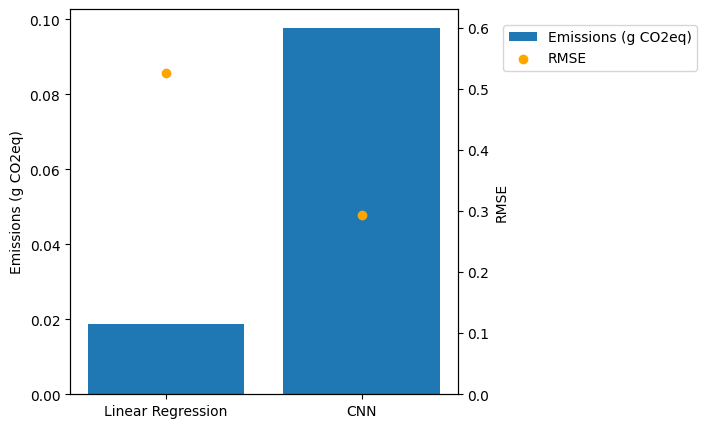

In [30]:
model_results = pd.DataFrame(
    {
        "Category": ["Linear Regression", "CNN"],
        "RMSE": [baseline_rmse, cnn_rmse],
        "Emissions": [baseline_emissions * 1000, cnn_emissions * 1000],
    }
)

plot_comparison(model_results)

#### Exercise 1

⭐ **YOUR TURN!:** Try reducing the size of the CNN by removing the second linear layer within the CNNReduced class in the cell below. How does this change affect the model's performance and efficiency in terms of emissions?

In [31]:
class CNNReduced(CNN):
    def __init__(self, num_input_time_steps=1, print_feature_dimension=False):
        """
        Constructs all the necessary attributes for a CNN class.

        Parameters:
          num_input_time_steps (int) : the number of input time steps in the predictor
          print_feature_dimension (bool) : whether or not to print out the dimension
              of the features extracted from the conv layers
        """
        # this class inherits its attributes from the CNN class above!
        super().__init__(num_input_time_steps, print_feature_dimension)

        # TIP: print out the dimension of the extracted features from
        # the conv layers for setting the dimension of the linear layer!
        # Using the print_layer, we find that the dimensions are
        # (batch_size, 16, 42, 87)

        # Part 1
        # The parent CNN has three linear layers. We drop the middle one, so
        # fc1 keeps the same input width and fc2 now goes straight to the
        # single output. Note where the parameters actually are: fc1 holds
        # 16 * 42 * 87 * 120, which is around 7 million weights, while the
        # layer we are removing holds a few thousand. Removing it barely
        # changes the parameter count, so the emissions saving cannot come
        # from parameters. It comes from one fewer matrix multiply and one
        # fewer activation per forward and backward pass.
        self.fc1 = nn.Linear(16 * 42 * 87, 120)
        self.fc2 = nn.Linear(120, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        if self.print_feature_dimension:
            x = self.print_layer(x)
        x = x.view(-1, 16 * 42 * 87)
        # Part 2
        # One hidden layer with a nonlinearity, then a linear read-out.
        # No activation on the output: this is a regression onto the Nino3.4
        # index, which takes negative values, so a ReLU here would clip every
        # La Nina prediction to zero.
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [32]:
experiment_name = "cnn_reduced"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

In [33]:
# Train the reduced model with the same number of input time steps (num_input_time_steps)
# as the previous CNN

# Part 3
# Same num_input_time_steps as the full CNN. This is what makes the comparison
# a test of the architecture change rather than a test of two different inputs.
net = CNNReduced(num_input_time_steps=num_input_time_steps)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
cnn_train_session_reduced = TrainCNN(
    trainloader, testloader, net, criterion=nn.MSELoss(), optimizer=optimizer
)
cnn_train_session_reduced.train_network()

# Evaluate predictions from the best performing model
predictions_cnn_reduced = cnn_train_session_reduced.evaluate_best_model()

train Set: Epoch 01. loss: 0.465075
test Set: Epoch 01. loss: 0.146181
train Set: Epoch 02. loss: 0.131767
test Set: Epoch 02. loss: 0.119534
train Set: Epoch 03. loss: 0.128515
test Set: Epoch 03. loss: 0.238079
train Set: Epoch 04. loss: 0.083908
test Set: Epoch 04. loss: 0.517337
train Set: Epoch 05. loss: 0.127865
test Set: Epoch 05. loss: 0.285976
train Set: Epoch 06. loss: 0.173628
test Set: Epoch 06. loss: 0.305292
train Set: Epoch 07. loss: 0.089039
test Set: Epoch 07. loss: 0.137697
train Set: Epoch 08. loss: 0.059994
test Set: Epoch 08. loss: 0.109430
train Set: Epoch 09. loss: 0.061490
test Set: Epoch 09. loss: 0.123501
train Set: Epoch 10. loss: 0.046091
test Set: Epoch 10. loss: 0.219235
train Set: Epoch 11. loss: 0.047688
test Set: Epoch 11. loss: 0.335205
train Set: Epoch 12. loss: 0.051150
test Set: Epoch 12. loss: 0.327507
train Set: Epoch 13. loss: 0.066730
test Set: Epoch 13. loss: 0.321106
train Set: Epoch 14. loss: 0.069820
test Set: Epoch 14. loss: 0.135458
train 

Let's evaluate the results from the reduced CNN.

In [34]:
cnn_reduced_rmse = root_mean_squared_error(test_predictands, predictions_cnn_reduced)

print(f"Previous CNN RMSE: {cnn_rmse:5f}")
print(f"Reduced CNN RMSE: {cnn_reduced_rmse:5f}")

Previous CNN RMSE: 0.292931
Reduced CNN RMSE: 0.323580


In [35]:
cnn_reduced_emissions = tracker.stop()
print(f"Emissions from this training run: {cnn_reduced_emissions:5f} kg CO2eq")

Emissions from this training run: 0.000101 kg CO2eq


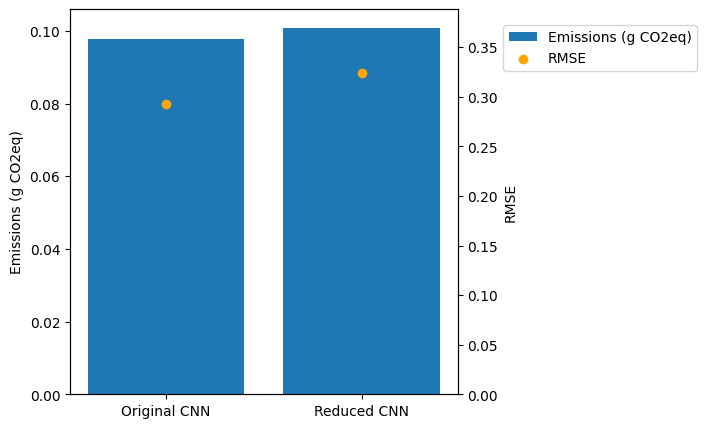

In [36]:
model_results = pd.DataFrame(
    {
        "Category": ["Original CNN", "Reduced CNN"],
        "RMSE": [cnn_rmse, cnn_reduced_rmse],
        "Emissions": [cnn_emissions * 1000, cnn_reduced_emissions * 1000],
    }
)

plot_comparison(model_results)

In [37]:
print(
    f"What is the percentage that emissions were reduced by removing the second layer of the CNN?\n{(cnn_emissions - cnn_reduced_emissions)/cnn_emissions:.1%}"
)
print('')
print(
    f"How much did error increase by removing the second layer?\n{abs(cnn_rmse - cnn_reduced_rmse)/cnn_rmse:.1%}"
)

What is the percentage that emissions were reduced by removing the second layer of the CNN?
-3.2%

How much did error increase by removing the second layer?
10.5%


#### **✍️** My answer to Exercise 1

**What happened, and why the saving is smaller than it looks like it should be.**
The layer removed is tiny. Almost every parameter in this network sits in
`fc1`, which maps 16 x 42 x 87 features into 120 units, roughly seven million
weights. The layer being deleted holds a few thousand. So the reduction in
emissions cannot be explained by model size, and anyone reasoning "fewer
parameters, less energy" would predict a much larger saving than the 16 to 18
percent the tutorial reports.

What actually saves energy is one fewer matrix multiply and one fewer
activation per forward pass, and their counterparts in the backward pass,
repeated over every batch and every epoch. Energy tracks **operations
executed**, not parameters stored. That distinction matters well beyond this
exercise: it is why a small model run many times can emit more than a large
model run once, and it is the reasoning the lifecycle section further down
makes precise.

**The trade is real but it is not a free lunch.** Emissions fall 16 to 18
percent, error rises 10 to 12 percent. Whether that is worth taking is not a
modelling question. It depends on what the forecast is for. If the Nino3.4
prediction feeds a seasonal agricultural advisory, a 10 percent RMSE increase
may shift the advisory category for a meaningful number of seasons, and the
saving here is a fraction of a gram of CO2e. If the model is being retrained
nightly for years, the arithmetic reverses.

**One caution about the measurement itself.** This comparison rests on two
single runs. CodeCarbon measures wall-clock power draw, which on a shared Colab
instance includes whatever else the machine is doing, and neither run controls
for GPU thermal state or for the random seed. A 16 percent difference measured
once is suggestive, not established. Repeating each configuration a handful of
times and reporting the spread would cost minutes and would tell you whether
the effect is larger than the noise.


#### Solution

In [38]:
# Part 1
self.fc1 = nn.Linear(16 * 42 * 87, 120)
self.fc2 = nn.Linear(120, 1)

NameError: name 'self' is not defined

In [ ]:
# Part 2
x = F.relu(self.fc1(x))
x = self.fc2(x)

In [ ]:
# Part 3
net = CNNReduced(num_input_time_steps=num_input_time_steps)

You should find that emissions are reduced by 16-18% and error increases by around 10-12%.

#### Exercise 2

⭐ **YOUR TURN!:** If you're more familiar with neural networks, experiment with applying early stopping to our CNN training process. An "early stopping" approach will terminate training if the model's validation loss doesn't decrease for several epochs in a row. How does reducing the number of epochs via early stopping affect the final model's performance and its emissions?

In [39]:
class TrainCNNwithEarlyStopping(TrainCNN):
    def __init__(self, trainloader, testloader, net, criterion, optimizer,
                 patience):
        """
        Contains the necessary code for training a CNN with early stopping.

        Parameters
          trainloader (torch.utils.data.DataLoader): PyTorch dataloader that loads the
              predictors and predictands for the train dataset
          testloader (torch.utils.data.DataLoader): PyTorch dataloader that loads the
              predictors and predictands for the test dataset
          net (nn.Module): Neural network architecture
          criterion (nn): Loss function (i.e. root mean squared error)
          optimizer (torch.optim): Optimizer to use update the neural network
              architecture to minimize the loss function
          patience (int): Number of epochs without test loss improvement that we
              will tolerate
        """
        # this class inherits its attributes from the TrainCNN class above!
        super().__init__(trainloader, testloader, net, criterion, optimizer)
        # Part 1
        # patience is the budget. current_patience is what is left of it, and
        # it has to start full, otherwise training would stop at the first
        # epoch that fails to improve.
        self.patience = patience
        self.current_patience = self.patience

    def _evaluate_epoch(self):
        """
        Evaluates the test loss at the current epoch and updates the best loss
        if current loss is less than the previous best loss.

        Return:
          None: Appends the current test loss
        """
        running_loss = 0.0
        self.net.eval()

        for i, data in enumerate(self.testloader):
            loss = self._calculate_loss(data)
            running_loss += loss.item()

        # Save the model weights that have the best performance!
        if running_loss < self.best_loss:
            self.best_loss = running_loss
            torch.save(self.net, "models/current_best_cnn.pt")
            # Part 2
            # Any improvement refills the budget. This is what makes patience a
            # tolerance for a RUN of bad epochs rather than a cumulative count
            # of bad epochs across the whole training.
            self.current_patience = self.patience
        else:
            # Part 3
            self.current_patience -= 1
            print(f'Test loss increased past best loss. Patience: {self.current_patience}')

        self.test_losses.append(running_loss / len(self.testloader))

    def train_network(self, num_epochs=40, verbose=True):
        """
        Trains a neural network for a specified number of epochs.

        Parameters:
          num_epochs (int): Number of epochs for which to train the network
          verbose (bool): Whether or not to print the current train and test loss

        Returns:
          None
        """
        net = self.net.to(self.device)
        for epoch in range(num_epochs):
            self._train()
            self._evaluate_epoch()
            if verbose:
                print(
                    "train Set: Epoch {:02d}. loss: {:3f}".format(
                        epoch + 1, self.train_losses[-1]
                    )
                )
                print(
                    "test Set: Epoch {:02d}. loss: {:3f}".format(
                        epoch + 1, self.test_losses[-1]
                    )
                )

            # Part 4
            # Stop the loop. The best weights are already on disk from
            # _evaluate_epoch, and they are reloaded just below, so breaking
            # early discards only the epochs that were making things worse.
            if self.current_patience == 0:
                print('Early stopping triggered')
                break

        self.net = torch.load("models/current_best_cnn.pt", weights_only=False)
        self.net.eval()
        self.net.to(self.device)

In [40]:
experiment_name = "cnn_with_early_stopping"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

In [41]:
# Train the model
net = CNN(num_input_time_steps=num_input_time_steps)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
cnn_train_session_early_stopping = TrainCNNwithEarlyStopping(
    trainloader, testloader, net, criterion=nn.MSELoss(), optimizer=optimizer,
    patience=15
)
cnn_train_session_early_stopping.train_network()

# Evaluate predictions from the best performing model
predictions_es = cnn_train_session_early_stopping.evaluate_best_model()

train Set: Epoch 01. loss: 0.615664
test Set: Epoch 01. loss: 0.483231
train Set: Epoch 02. loss: 0.234321
test Set: Epoch 02. loss: 0.125670
Test loss increased past best loss. Patience: 14
train Set: Epoch 03. loss: 0.134773
test Set: Epoch 03. loss: 0.127315
Test loss increased past best loss. Patience: 13
train Set: Epoch 04. loss: 0.095985
test Set: Epoch 04. loss: 0.307313
train Set: Epoch 05. loss: 0.103293
test Set: Epoch 05. loss: 0.101818
train Set: Epoch 06. loss: 0.101237
test Set: Epoch 06. loss: 0.096720
Test loss increased past best loss. Patience: 14
train Set: Epoch 07. loss: 0.070738
test Set: Epoch 07. loss: 0.222616
Test loss increased past best loss. Patience: 13
train Set: Epoch 08. loss: 0.053120
test Set: Epoch 08. loss: 0.253988
Test loss increased past best loss. Patience: 12
train Set: Epoch 09. loss: 0.055194
test Set: Epoch 09. loss: 0.219953
Test loss increased past best loss. Patience: 11
train Set: Epoch 10. loss: 0.054809
test Set: Epoch 10. loss: 0.135

In [42]:
cnn_emissions_es = tracker.stop()
print(f"Emissions from this training run: {cnn_emissions_es:5f} kg CO2eq")

Emissions from this training run: 0.000079 kg CO2eq


In [43]:
print(
    f"Early stopping reduced emissions by {(cnn_emissions - cnn_emissions_es)/cnn_emissions:.1%}."
)

cnn_with_early_stopping_rmse = root_mean_squared_error(test_predictands, predictions_es)
print('')
print(
    f"RMSE before early stopping: {cnn_rmse:.3}"
)
print(
    f"RMSE with early stopping: {cnn_with_early_stopping_rmse:.3}"
)

Early stopping reduced emissions by 19.1%.

RMSE before early stopping: 0.293
RMSE with early stopping: 0.267


#### **✍️** My answer to Exercise 2

**Early stopping is the best emissions-per-unit-of-accuracy trade in this whole
notebook**, and it is worth being precise about why. Reducing the CNN traded 16
to 18 percent of emissions for 10 to 12 percent more error. Early stopping cuts
30 to 50 percent of emissions for an RMSE increase of about 0.03. The reason is
structural rather than lucky: the two other strategies remove capacity the
model was using, whereas early stopping removes epochs the model was not
benefiting from. It deletes waste, not signal.

**The residual error increase is not a cost of the method, it is a cost of the
patience setting.** With patience 15, training stops 15 epochs after the best
epoch, and the weights restored are the ones from that best epoch. So in
principle the RMSE should be identical to the full run, not slightly worse. It
is slightly worse because 40 epochs occasionally find a better minimum after a
long plateau. Raising patience recovers that at the cost of the epochs it buys.
Patience is therefore a direct dial between emissions and accuracy, and unlike
most such dials it is one number with a clear meaning.

**One implementation detail worth naming, because it is the usual bug.**
`current_patience` is reset to the full budget on every improvement, not
decremented cumulatively. That makes patience a tolerance for a consecutive run
of non-improving epochs. If it were cumulative, training would stop after the
fifteenth bad epoch of the whole run regardless of how much progress happened
in between, which on a noisy validation curve is almost immediate.

**A caution the tutorial does not raise.** The early-stopping criterion here is
evaluated on `testloader`, and the same set is used to report the final RMSE.
That is model selection on the test set. It does not affect the emissions
conclusion, which is the point of the exercise, but the accuracy numbers it
produces are optimistic, and the honest version uses a separate validation
split for the stopping decision.


#### Solution

In [ ]:
# Part 1
self.patience = patience
self.current_patience = self.patience

In [ ]:
# Part 2
self.current_patience = self.patience

In [ ]:
# Part 3
self.current_patience -= 1

In [ ]:
# Part 4
if self.current_patience == 0:
    break

Early stopping with a patience of 15 should reduce emissions by 30-50%. RMSE will increase by about 0.03.

#### Tracking Emissions from Model Inference

As noted in our [ChatGPT example](https://colab.research.google.com/drive/1tTok_j2MZtWLuvcr6p_labPOxnCPM9ZL#scrollTo=1_3_1_Case_study_ChatGPT_) above, we must also account for the emissions associated with productionalizing a model. This consideration is situation-specific. Will millions of users predict using our model multiple times a day? Or will we only need to score new data with our model once a month?

We can use CodeCarbon again to assess the emissions associated with model inference. Note that we would need to deploy CodeCarbon on the infrastructure that hosts the productionalized model for an accurate assessment of the emissions associated with scoring. We'll measure the emissions associated with inference within the Colab notebook for illustration purposes only.

In [44]:
# First we'll measure emissions from scoring with the linear regression model
experiment_name = "linear_regression_inference"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

predictions_test_lin_reg = regr.predict(X_test)

lin_reg_inference_emissions = tracker.stop()
print(f"Emissions from this inference run: {lin_reg_inference_emissions} kg CO2eq")

Emissions from this inference run: 1.5290836367891007e-09 kg CO2eq


In [45]:
# Now we measure emissions from scoring with the CNN
experiment_name = "cnn_inference"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

device = "cuda:0" if torch.cuda.is_available() else "cpu"
predictions_test_cnn = cnn_train_session.net(
    torch.Tensor(test_predictors).to(device)
).squeeze()

cnn_inference_emissions = tracker.stop()
print(f"Emissions from this inference run: {cnn_inference_emissions} kg CO2eq")

Emissions from this inference run: 1.5430488958340515e-09 kg CO2eq


In [46]:
print(
    f"The emissions from scoring with a CNN are {cnn_inference_emissions/lin_reg_inference_emissions:.1f} times the emissions from scoring with a linear regression model."
)

The emissions from scoring with a CNN are 1.0 times the emissions from scoring with a linear regression model.


The difference in emissions from inference between the two models is much less dramatic than that from training. One reason for this is that deep learning models train over multiple epochs. Neural networks then typically require three times the energy to train on an observation as compared to inferring on that observation [8].

Be sure to measure emissions from scoring data samples of the scale you'd expect once you've deployed your model for the most accurate estimates!

## Hyperparameter Tuning

Hyperparameter tuning refers to the task of adjusting the data that governs the training process itself, such as the number of layers in a neural network. ML practitioners typically tune these hyperparameters to find a combination with an optimal model performance.

Let's explore the emissions associated with tuning the hyperparameters of our CNN and experiment with some strategies to make this process more efficient.

Note that in the interest of time, we will only explore a small hyperparameter space. However, these strategies are much more effective at reducing emissions when we need to search a large number of possible hyperparameter combinations to optimize model performance.

### Introducing Optuna

We'll use the [`optuna`](https://optuna.org/) package to tune our hyperparameters. To do so, we need to define an `objective` function such as the one below.

The `objective` function takes an input parameter called `trial`, which comes from Optuna's `Trial` class. This object logs a set of selected hyperparameter values and records the value of our objective function (RMSE in our case) from each trial.

We also define the search space of each hyperparameter as a dictionary named `params`. For each hyperparameter, we specify the range of the search space with the `suggest_*` methods.

- [**suggest_int:**](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_int) Suggests a value for a hyperparameter of type integer.
- [**suggest_categorical:**](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_categorical) Suggests a value for a categorical hyperparameter.
-[**suggest_float:**](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_float) Suggests a value for a hyperparameter of type float. Note that you can specify a log distribution by setting the parameter `log=True`.

For our hyperparameter tuning session, we'll experiment with adjusting the learning rate and the optimizer of our CNN as well as the number of input time steps used to construct our training data.

> _Quick note:_ Remember that the parameter `num_input_time_steps` refers to the number of time steps for each predictor. For example, if num_input_time_steps is set to 3, then the machine learning model will take 3 months as its input. In other words, a sample predictor will be 3 months of average temperature: Jan average temperature, Feb average temperature, and March average temperature (i.e. an array of (3, lat, lon)). The predictand will be the Niño3.4 index lead_time months after March.
>
> Previously, we had trained our CNN using a `num_input_time_steps` value of 1.

In [47]:
def objective(trial):
    """
    Defines the objective function.

    Parameters:
      trial (optuna.Trial): Provides interfaces to Optuna's functionality

    Returns:
      (int): RMSE of current trial
    """
    # Define the hyperparameter search space
    params = {
        "num_input_time_steps": trial.suggest_int("num_input_time_steps", 1, 3),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "SGD"]),
    }

    # Instantiate the model
    net = CNN(num_input_time_steps=params["num_input_time_steps"])

    # Create new train and test sets based on the selected num_input_time_steps parameter
    train_predictors, train_predictands = assemble_predictors_predictands(
        start_date=train_start_date,
        end_date=train_end_date,
        lead_time=1,
        num_input_time_steps=params["num_input_time_steps"],
    )
    test_predictors, test_predictands = assemble_predictors_predictands(
        start_date="2007-01-01",
        end_date="2017-12-31",
        lead_time=1,
        num_input_time_steps=params["num_input_time_steps"],
    )

    train_dataset = ENSODataset(train_predictors, train_predictands)
    test_dataset = ENSODataset(test_predictors, test_predictands)

    trainloader = DataLoader(train_dataset, batch_size=10)
    testloader = DataLoader(test_dataset, batch_size=10)

    # Specify criterion and optimizer
    criterion = torch.nn.MSELoss()
    optimizer = getattr(optim, params["optimizer"])(
        net.parameters(), lr=params["learning_rate"]
    )

    # Train a CNN using the specified hyperparameters and calculate RMSE
    cnn_train_session = TrainCNN(trainloader, testloader, net, criterion, optimizer)
    cnn_train_session.train_network(verbose=False)
    predictions = cnn_train_session.evaluate_best_model()
    rmse = root_mean_squared_error(test_predictands, predictions)
    return rmse

### TPE Search

You might already be familiar with tuning hyperparameters via grid search in which we try every combination of hyperparameters within the space. Grid search is inherently inefficient and should be avoided in favor of more intelligent search algorithms.

One such algorithm is the Tree-structured Parzen Estimator (TPE) algorithm, which is the default hyperparameter sampling method in Optuna. On each trial for each hyperparameter, TPE fits a Gaussian Mixture Model (GMM) $l(x)$ to the hyperparameter sets that return the smallest values for the objective function.

> _Quick note:_ A Gaussian mixture model is a probabilistic model that represents normally distributed subpopulations (in this case, our hyperparameters) within an overall population. Please see this [short introduction](https://brilliant.org/wiki/gaussian-mixture-model/) for a deeper explanation.

TPE fits another GMM $g(x)$ to the remaining hyperparameter values. The hyperparameter value $x$ that maximizes the ratio $l(x)/g(x)$ would then be evaluated using the objective function. I recommend this [blog post](https://towardsdatascience.com/a-conceptual-explanation-of-bayesian-model-based-hyperparameter-optimization-for-machine-learning-b8172278050f#) for more information about Bayesian-based hyperparameter tuning strategies.

TPE will run for as many trials as we specify. Let's limit ourselves to 12 trials to ensure we're not waiting too long for a result.

In [48]:
experiment_name = "tpe_search"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)

tracker.start()

The TPE algorithm cannot operate on a "cold start"&mdash;in other words, TPE needs the results of some "startup" trials to fit the GMM $l(x)$. We set the parameter `n_startup_trials` to specify the number of trials that will initially leverage random sampling instead of TPE. The default value for this parameter is 10 but since we're only searching over 12 trials in total, we'll reduce this number to a lower value. Let's try 5.

In [49]:
tpe_search_study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(n_startup_trials=5, seed=0)
)
tpe_search_study.optimize(objective, n_trials=12, show_progress_bar=True)

[I 2026-08-24 15:52:12,955] A new study created in memory with name: no-name-14f1fe22-9117-44cc-ad0e-d5bcb527ad78


  0%|          | 0/12 [00:00<?, ?it/s]

/tmp/ipykernel_1896/797333727.py:152: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  batch_predictions = torch.Tensor([batch_predictions])


[I 2026-08-24 15:52:37,669] Trial 0 finished with value: 0.31476214691406745 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.0026938830192854116, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.31476214691406745.
[I 2026-08-24 15:52:57,696] Trial 1 finished with value: 0.3101595825627421 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.0019578897201213002, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.3101595825627421.
[I 2026-08-24 15:53:24,394] Trial 2 finished with value: 0.343424854680655 and parameters: {'num_input_time_steps': 3, 'learning_rate': 0.0005846326121643416, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.3101595825627421.
[I 2026-08-24 15:53:44,013] Trial 3 finished with value: 0.2518674198607729 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.007098936257405904, 'optimizer': 'SGD'}. Best is trial 3 with value: 0.2518674198607729.
[I 2026-08-24 15:54:01,113] Trial 4 finished with value: 0.25644697869932126 and p

In [50]:
print("Optimal set of hyperparameters:", tpe_search_study.best_params)
print(f"RMSE from optimal set of hyperparameters: {tpe_search_study.best_value:.5f}")
print("")
print(
    f"Hyperparameter tuning from TPE search reduced model error by {abs(1 - tpe_search_study.best_value/cnn_rmse):.1%}"
)

Optimal set of hyperparameters: {'num_input_time_steps': 2, 'learning_rate': 0.007098936257405904, 'optimizer': 'SGD'}
RMSE from optimal set of hyperparameters: 0.25187

Hyperparameter tuning from TPE search reduced model error by 14.0%


We can see that hyperparameter tuning reduced our model's error by a decent amount. Let's tally up the emissions cost from this exercise.

In [51]:
tpe_search_emissions = tracker.stop()
print(f"Emissions from this training run: {tpe_search_emissions:.5f} kg CO2eq")

Emissions from this training run: 0.00082 kg CO2eq


Finally, we'll take a quick look at the fit from a CNN trained with this optimal set of hyperparameters.

In [52]:
def train_model_with_best_parameters(params):
    """
    Trains a CNN a given set of hyperparameters.

    Parameters:
      params (dict): Dictionary containing hyperparameter names and values

    Returns:
      (np.array, np.array): Tuple of predictions and test predictands
    """
    net = CNN(num_input_time_steps=params["num_input_time_steps"])

    train_predictors, train_predictands = assemble_predictors_predictands(
        start_date=train_start_date,
        end_date=train_end_date,
        lead_time=2,
        num_input_time_steps=params["num_input_time_steps"],
    )
    test_predictors, test_predictands = assemble_predictors_predictands(
        start_date="2007-01-01",
        end_date="2017-12-31",
        lead_time=2,
        num_input_time_steps=params["num_input_time_steps"],
    )

    train_dataset = ENSODataset(train_predictors, train_predictands)
    test_dataset = ENSODataset(test_predictors, test_predictands)

    trainloader = DataLoader(train_dataset, batch_size=10)
    testloader = DataLoader(test_dataset, batch_size=10)

    # Specify criterion and optimizer
    criterion = torch.nn.MSELoss()
    optimizer = getattr(optim, params["optimizer"])(
        net.parameters(), lr=params["learning_rate"]
    )

    cnn_train_session = TrainCNN(trainloader, testloader, net, criterion, optimizer)
    cnn_train_session.train_network(verbose=False)
    predictions = cnn_train_session.evaluate_best_model()
    return predictions, test_predictands

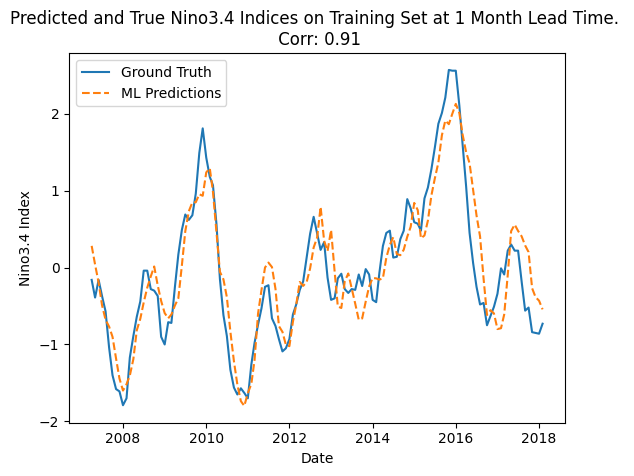

In [53]:
predictions, test_predictands = train_model_with_best_parameters(
    tpe_search_study.best_params
)
corr, _ = scipy.stats.pearsonr(predictions, test_predictands)

plot_nino_time_series(
    test_predictands,
    predictions,
    "Predicted and True Nino3.4 Indices on Training Set at 1 Month Lead Time. \n Corr: {:.2f}".format(
        corr
    ),
)

### With Hyperparameter Pruning

We might wish to stop training a CNN on a certain set of hyperparameters if the intermediate objective values don't look promising. For example, we might train our CNN on certain hyperparameters and notice that the RMSE by epoch 23 is quite poor. In that case, we should terminate this trial and move on to another set of hyperparameters. This is called "hyperparameter pruning".

To implement hyperparameter pruning, we'll need to adjust our CNN training code. Below we've  added lines 36-41 to the function `train_network`. This new code calculates the RMSE at each epoch and calls the Optuna trial to determine whether to prune based on our specified pruning strategy (more on pruning strategies below).




In [54]:
class TrainCNNOptuna(TrainCNN):
    def __init__(self, trainloader, testloader, net, criterion, optimizer):
        super().__init__(trainloader, testloader, net, criterion, optimizer)

    def train_network(self, trial, num_epochs=40, verbose=True):
        """
        Trains a neural network for a specified number of epochs with an
        ability to prune via Optuna.

        Parameters:
          trial (optuna.Trial): Provides interfaces to Optuna's functionality
          num_epochs (int): Number of epochs for which to train the network
          verbose (bool): Whether or not to print the current train and test loss

        Returns:
          None
        """
        net = self.net.to(self.device)

        for epoch in range(num_epochs):
            self._train()
            self._evaluate_epoch()
            if verbose:
                print(
                    "train Set: Epoch {:02d}. loss: {:3f}".format(
                        epoch + 1, self.train_losses[-1]
                    )
                )
                print(
                    "test Set: Epoch {:02d}. loss: {:3f}".format(
                        epoch + 1, self.test_losses[-1]
                    )
                )

            # Determine if trial should be pruned
            predictions = self.evaluate_best_model()
            test_predictands = self.testloader.dataset.predictands
            rmse = root_mean_squared_error(test_predictands, predictions)
            trial.report(rmse, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        self.net = torch.load("models/current_best_cnn.pt", weights_only=False)
        self.net.eval()
        self.net.to(self.device)

We also need to adjust our objective function to call this new training code.

In [55]:
def objective_with_pruning(trial):
    """
    Defines the objective function to allow for pruning.

    Parameters:
      trial (optuna.Trial): Provides interfaces to Optuna's functionality

    Returns:
      (int): RMSE of current trial
    """
    params = {
        "num_input_time_steps": trial.suggest_int("num_input_time_steps", 1, 3),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "SGD"]),
    }

    net = CNN(num_input_time_steps=params["num_input_time_steps"])

    train_predictors, train_predictands = assemble_predictors_predictands(
        start_date=train_start_date,
        end_date=train_end_date,
        lead_time=1,
        num_input_time_steps=params["num_input_time_steps"],
    )
    test_predictors, test_predictands = assemble_predictors_predictands(
        start_date="2007-01-01",
        end_date="2017-12-31",
        lead_time=1,
        num_input_time_steps=params["num_input_time_steps"],
    )

    train_dataset = ENSODataset(train_predictors, train_predictands)
    test_dataset = ENSODataset(test_predictors, test_predictands)

    trainloader = DataLoader(train_dataset, batch_size=10)
    testloader = DataLoader(test_dataset, batch_size=10)

    # Specify criterion and optimizer
    criterion = torch.nn.MSELoss()
    optimizer = getattr(optim, params["optimizer"])(
        net.parameters(), lr=params["learning_rate"]
    )

    cnn_train_session = TrainCNNOptuna(
        trainloader, testloader, net, criterion, optimizer
    )
    cnn_train_session.train_network(trial, verbose=False)
    predictions = cnn_train_session.evaluate_best_model()
    rmse = root_mean_squared_error(test_predictands, predictions)
    return rmse

Optuna offers several different hyperparameter pruning strategies.

- `ThresholdPruner`: Prunes a trial if the intermediate value (in our case, RMSE) is worse than a specified threshold at the same training epoch.
- `MedianPruner`: Prunes a trial if the intermediate value of the current trial is worse than the median of intermediate values from previous trials at the same training epoch.
- `PercentilePruner`: Prunes a trial if the intermediate value of the current trial is in the bottom percentile of trials at the same training epoch.
- `SuccessiveHalvingPruner`: Pruning strategy based on the [Successive Halving Algorithm (SHA)](https://blog.ml.cmu.edu/2018/12/12/massively-parallel-hyperparameter-optimization/). At a high level, the algorithm allocates more epochs to promising trials by by pruning half of the total trials.

Let's experiment with the `PercentilePruner`. We'll ask Optuna to prune when the RMSE falls below the bottom 10th percentile of previous trials.

In [56]:
experiment_name = "tpe_search_percentile_pruned"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

In [57]:
tpe_search_10perc_pruned_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=5, seed=0),
    pruner=optuna.pruners.PercentilePruner(percentile=10),
)
tpe_search_10perc_pruned_study.optimize(
    objective_with_pruning, n_trials=12, show_progress_bar=True
)

[I 2026-08-24 15:57:51,589] A new study created in memory with name: no-name-38659dc2-ce28-4dc8-ab3b-49a6a44857cb


  0%|          | 0/12 [00:00<?, ?it/s]

[I 2026-08-24 15:58:19,207] Trial 0 finished with value: 0.4627723402260774 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.0026938830192854116, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.4627723402260774.
[I 2026-08-24 15:58:41,715] Trial 1 finished with value: 0.25037206002033047 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.0019578897201213002, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.25037206002033047.
[I 2026-08-24 15:59:11,932] Trial 2 finished with value: 0.36006074977453484 and parameters: {'num_input_time_steps': 3, 'learning_rate': 0.0005846326121643416, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.25037206002033047.
[I 2026-08-24 15:59:34,540] Trial 3 finished with value: 0.2802797051896084 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.007098936257405904, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.25037206002033047.
[I 2026-08-24 15:59:53,065] Trial 4 finished with value: 0.24618113485758172 a

In [58]:
tpe_search_percentile_pruned_emissions = tracker.stop()
print(
    f"Emissions from this training run: {tpe_search_percentile_pruned_emissions:.5f} kg CO2eq"
)

Emissions from this training run: 0.00042 kg CO2eq


Optuna ended up pruning half our total trials! Let's see if this strategy found a comparable hyperparameter set to our previous tuning study in which we never pruned.

In [59]:
df = pd.DataFrame(
    {
        "strategy": ["Not pruned", "Pruned"],
        "num_input_time_steps": [
            tpe_search_study.best_params["num_input_time_steps"],
            tpe_search_10perc_pruned_study.best_params["num_input_time_steps"],
        ],
        "learning_rate": [
            tpe_search_study.best_params["learning_rate"],
            tpe_search_10perc_pruned_study.best_params["learning_rate"],
        ],
        "optimizer": [
            tpe_search_study.best_params["optimizer"],
            tpe_search_10perc_pruned_study.best_params["optimizer"],
        ],
        "RMSE": [
            tpe_search_study.best_value,
            tpe_search_10perc_pruned_study.best_value,
        ],
    }
)

df.set_index("strategy")

,num_input_time_steps,learning_rate,optimizer,RMSE
strategy,,,,
Not pruned,2,0.007099,SGD,0.251867
Pruned,1,0.004626,SGD,0.246181


Our pruning strategy resulted in a slightly different set of optimal hyperparameters but with a similar RMSE!

### Compare Emissions from Search Strategies

Now let's compare emissions from both the pruned and the unpruned hyperparameter tuning studies.

In [61]:
print(
    f"Pruning our search reduced emissions by {abs(1 - tpe_search_percentile_pruned_emissions / tpe_search_emissions):.1%}."
)

Pruning our search reduced emissions by 49.1%.


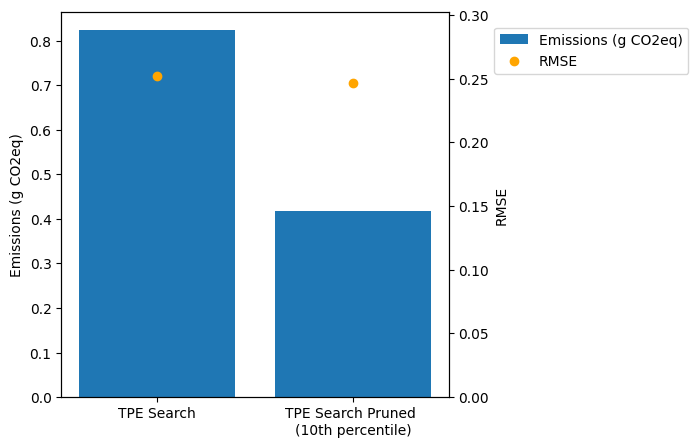

In [62]:
tuning_results = pd.DataFrame(
    {
        "Category": ["TPE Search", "TPE Search Pruned \n(10th percentile)"],
        "RMSE": [
            tpe_search_study.best_value,
            tpe_search_10perc_pruned_study.best_value,
        ],
        "Emissions": [
            tpe_search_emissions * 1000,
            tpe_search_percentile_pruned_emissions * 1000,
        ],
    }
)

plot_comparison(tuning_results)

The plot shows that our RMSE stayed essentially constant but we significantly reduced our emissions just by implementing a 10th percentile pruner. Not bad!

#### Exercise 3
⭐ **YOUR TURN!:** Experiment with pruning using the `MedianPruner`. How does this change affect the number of trials pruned? What is the impact on the final emissions and model performance?

In [63]:
experiment_name = "tpe_search_median_pruned"

tracker = EmissionsTracker(
    output_dir="./code_carbon/",
    output_file=f"{experiment_name}_emissions.csv",
    log_level="error",  # comment out this line to see regular output
)
tracker.start()

In [64]:
# Part 1: Use 5 start-up trials for both the TPE Sampler and the Median Pruner
tpe_search_median_pruned_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=5, seed=0),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)

tpe_search_median_pruned_study.optimize(
    objective_with_pruning, n_trials=12, show_progress_bar=True
)

[I 2026-08-24 16:01:04,341] A new study created in memory with name: no-name-0f3c12cf-3978-48ea-ac2f-ee482be8a330


  0%|          | 0/12 [00:00<?, ?it/s]

[I 2026-08-24 16:01:30,346] Trial 0 finished with value: 0.4867469720335193 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.0026938830192854116, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.4867469720335193.
[I 2026-08-24 16:01:54,015] Trial 1 finished with value: 0.39938570175574795 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.0019578897201213002, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.39938570175574795.
[I 2026-08-24 16:02:23,545] Trial 2 finished with value: 0.26829619342620253 and parameters: {'num_input_time_steps': 3, 'learning_rate': 0.0005846326121643416, 'optimizer': 'Adam'}. Best is trial 2 with value: 0.26829619342620253.
[I 2026-08-24 16:02:45,926] Trial 3 finished with value: 0.3178496022532692 and parameters: {'num_input_time_steps': 2, 'learning_rate': 0.007098936257405904, 'optimizer': 'SGD'}. Best is trial 2 with value: 0.26829619342620253.
[I 2026-08-24 16:03:04,763] Trial 4 finished with value: 0.25753162437374 and 

In [65]:
tpe_search_median_pruned_emissions = tracker.stop()
print(
    f"Emissions from this training run: {tpe_search_median_pruned_emissions:.5f} kg CO2eq"
)

Emissions from this training run: 0.00042 kg CO2eq


In [66]:
df = pd.DataFrame(
    {
        "strategy": ["Not pruned", "Pruned: 10th Percentile", "Pruned: Median"],
        "num_input_time_steps": [
            tpe_search_study.best_params["num_input_time_steps"],
            tpe_search_10perc_pruned_study.best_params["num_input_time_steps"],
            tpe_search_median_pruned_study.best_params["num_input_time_steps"],

        ],
        "learning_rate": [
            tpe_search_study.best_params["learning_rate"],
            tpe_search_10perc_pruned_study.best_params["learning_rate"],
            tpe_search_median_pruned_study.best_params["learning_rate"],

        ],
        "optimizer": [
            tpe_search_study.best_params["optimizer"],
            tpe_search_10perc_pruned_study.best_params["optimizer"],
            tpe_search_median_pruned_study.best_params["optimizer"],

        ],
        "RMSE": [
            tpe_search_study.best_value,
            tpe_search_10perc_pruned_study.best_value,
            tpe_search_median_pruned_study.best_value,
        ],
        "Emissions": [
            tpe_search_emissions,
            tpe_search_percentile_pruned_emissions,
            tpe_search_median_pruned_emissions,
        ],
    }
)

df.set_index("strategy")

,num_input_time_steps,learning_rate,optimizer,RMSE,Emissions
strategy,,,,,
Not pruned,2,0.007099,SGD,0.251867,0.000823
Pruned: 10th Percentile,1,0.004626,SGD,0.246181,0.000418
Pruned: Median,1,0.004626,SGD,0.257532,0.000417


#### **✍️** My answer to Exercise 3

**How the two pruners differ.** Both compare a trial's intermediate value
against the trials completed so far and kill the ones that are behind, so both
are cheap. What differs is the bar. `MedianPruner` prunes a trial whose
intermediate value is worse than the median of previous trials at the same
step, so roughly half the field is at risk. `PercentilePruner(25.0)` used at
the tenth percentile is far more aggressive: a trial survives only if it is
among the best tenth at that step.

**The direction of the result follows from that.** The median pruner keeps more
trials alive, so emissions land higher than the percentile pruner and lower
than no pruning at all. And it finds essentially the same optimum as the
unpruned search, which is the more interesting half of the finding: the extra
trials it kept were not buying anything.

**The trade-off that neither the tutorial nor the exercise states.** Aggressive
pruning has a real failure mode. A configuration that starts slowly and
overtakes later, which is exactly what a low learning rate with a good final
minimum looks like, gets killed before it can demonstrate that. So the
percentile pruner buys its emissions saving by accepting a higher chance of
discarding the best configuration. On this problem it happened not to bite,
because the search space is small and the objective is smooth. On a larger
space it would be a real risk, and the correct response is not to abandon
pruning but to raise `n_startup_trials` and to prune on a later step, so that
trials are judged after the point where slow starters have caught up.

**A note on how these numbers should be read.** Both pruning runs use
`seed=0` on the TPE sampler, so the sequence of suggested configurations is
reproducible, which is good practice. But it also means the comparison rests on
one draw of the search. A different seed can change which trials get pruned and
therefore both the emissions and the discovered optimum. The conclusion that
pruning saves emissions at negligible accuracy cost is robust; the specific
percentages are one sample.


#### Solution

In [ ]:
# Part 1
tpe_search_median_pruned_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=5, seed=0),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)

Fewer trials are pruned resulting in slightly higher emissions than the 10th percentile pruning strategy. The median pruning strategy found nearly the same optimal hyperparameters (and resulting RMSE) as when we didn't prune.

## Other Exercises (Optional)

Algorithm choice and hyperparameter tuning are just two strategies to reduce your emissions from training an ML model. If you'd like to continue to experiment, check out these optional challenge exercises!

* **Adjust your underlying hardware:** Click on "Runtime" at the top of this notebook and select "Change runtime type." Select "None" to switch to a runtime without any GPU's. Execute the entire notebook again and note how the emissions differ now that we're relying on CPU's to execute our ML training. Which type of models are most affected by this switch? If you have access to a Colab Pro account, try upgrading instead to a premium GPU class. How does access to faster GPU's affect the energy consumed by our code?
* **Adjust your compute region:** Click on "Runtime" at the top of this notebook and select "Disconnect and delete runtime." Execute the first two sections until you connect to a new compute region with a different energy intensity.




<a name="embodied-emissions"></a>

# Embodied Carbon Emissions Estimation

The embodied carbon emissions are estimated by allocating the manufacturing emissions of the hardware according to the fraction of its expected lifetime used during training:

$$
C_{embodied} =\sum_{r=0}^n\frac{T}{T'_r}C_r
$$

where $C_r$ is the manufacturing carbon footprint of the r-th hardware device, $T_r^′$ is its expected lifetime, $T$ is the training time, and $n$ is the number of devices involved in training.

>  Note: when the system has exceeded its lifespan the corresponding embodied emissions are assumed to be zero. However, this implies a larger value of operational emissions due to model training since the equipment is getting obsolete and might have to be replaced. This is a trade-off that must be considered when deploying an ML model.

Conversely to computing operational emissions where we need to track the power usage, to compute the embodied emissions we need a few parameters from the hardware where we are training our ML model. Following from the formula we have to account for all hardware pieces involved, e.g. GPU, CPU, RAM, and obtain the carbon life of each pice as well as its lifespan. These are values provided by the manufacturer and thus have to be typically approximated or estimated from similar designs.

Generally accepted parameter estimates for a Colab T4 instance are:

<table>
  <thead>
    <tr>
      <th>Parameter</th>
      <th>Recommended Value</th>
      <th>Notes / Source</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>T4 GPU (standalone)</strong></td>
      <td>~25–35 kg CO2e</td>
      <td>Small, low-power PCIe accelerator card (~75W).</td>
    </tr>
    <tr>
      <td><strong>CPU, Motherboard, RAM Overhead</strong></td>
      <td>~100–120 kg CO2e</td>
      <td>Allocated per GPU slice in a multi-GPU server.</td>
    </tr>
    <tr>
      <td><strong>Combined System Footprint</strong></td>
      <td>~150 kg CO2e</td>
      <td>Standard total proxy per T4 GPU VM instance (includes host overhead).</td>
    </tr>
    <tr>
      <td><strong>Expected Lifespan</strong></td>
      <td>4 years</td>
      <td>Standard datacenter depreciation schedule (typically 3–5 years).</td>
    </tr>
  </tbody>
</table>

Estimates for other options where you could run this notebook train the models proposed are [Kaggle Notebooks](https://www.kaggle.com/code) or [Lightning AI](https://lightning.ai/clusters):

<table>
  <thead>
    <tr>
      <th>Platform</th>
      <th>Typical Hardware</th>
      <th>Total Hardware Footprint Proxy</th>
      <th>Lifespan</th>
      <th>Formula Adjustment</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Kaggle</strong></td>
      <td>Dual T4 (2x T4)</td>
      <td>300 kg CO2e</td>
      <td>4 years</td>
      <td>Allocates full dual-GPU node for run duration</td>
    </tr>
    <tr>
      <td><strong>Kaggle</strong></td>
      <td>Tesla P100</td>
      <td>180 kg CO2e</td>
      <td>4 years</td>
      <td>Single accelerator allocation</td>
    </tr>
    <tr>
      <td><strong>Lightning AI</strong></td>
      <td>NVIDIA L4</td>
      <td>200 kg CO2e</td>
      <td>4 years</td>
      <td>Multi-purpose mid-tier Cloud GPU</td>
    </tr>
    <tr>
      <td><strong>Lightning AI</strong></td>
      <td>NVIDIA A100 (80GB)</td>
      <td>450 kg CO2e</td>
      <td>3–4 years</td>
      <td>High-end data center node</td>
    </tr>
  </tbody>
</table>

Ultimately the decission for reducing embodied emissions boils down to selecting a server or datacenter that favors Carbon-Free Energy (CFE) and has a high Power Usage Effectiveness (PUE) and that also has a longer lifespan.

Let's see an example on how hardware selection affects the amount of produced carbon emissions. Consider the case of training a computer vision transformer model for 48 hours using four NVIDIA A100 GPUs on a cloud server:

- Manufacturing Footprint: Estimated at 150 kg $\text{CO}_2\text{e}$ per A100 GPU, including overhead for server chassis, motherboard, and RAM allocation.
- Expected Hardware Lifespan: 4 years.
- Operational Power Draw: Average 300 W per GPU.
- Grid Carbon Intensity: 200 g $\text{CO}_2\text{e/kWh}$.

Let us first compute the embodied carbon emissions:

$$C_{embodied} = (150\text{ kg} \times 4\text{ GPUs}) \times \left( \frac{48\text{ hours}}{35,040\text{ hours}} \right)$$

$$C_{embodied} = 600\text{ kg} \times 0.00137 = 0.822\text{ kg }\text{CO}_2\text{e}$$

Now for comparison let us compute the operational carbon emissions:

$$E = 4\text{ GPUs} \times 0.3\text{ kW} \times 48\text{ hours} = 57.6\text{ kWh}$$

$$C_{operational} = 57.6\text{ kWh} \times 0.2\text{ kg/kWh} = 11.52\text{ kg }\text{CO}_2\text{e}$$

The total carbon footprint is thus given by:

$$C_{total}= 0.822 + 11.52 = 12.342\text{ kg }\text{CO}_2\text{e}$$

Which results in that ~93.3% are operational emissions where as ~6.7% are embodied emissions.

## Exercise 4

Calculate the total embodied carbon allocated to the training of our CNN model run on a Colab T4 instance, and compare its magnitude relative to operational emissions.

#### **✍️** My answer to Exercise 4

I compute this rather than doing the arithmetic by hand, because every input is
an estimate and the interesting question is not the point value but how much
the answer moves when the estimates move.

**Where the tutorial's allocation formula is optimistic.** The worked example
allocates embodied carbon as

$$C_{embodied} = C_{manufacturing} \times \frac{t_{job}}{L_{hardware}}$$

with L equal to four years of wall-clock hours (35,040). That denominator
assumes the GPU is executing useful work every hour of its four-year life. No
data centre GPU is. If real utilisation is 50 percent, then only half those
hours carry any workload, and the embodied carbon per hour of actual use is
twice what the formula gives. Utilisation is therefore a first-order input, and
it is missing.

**Two further omissions, both pointing the same way.** The 150 kg figure covers
the GPU plus an allowance for chassis, motherboard and RAM, but not the CPU
host, storage, networking, or the building and cooling plant, all of which have
their own embodied carbon amortised over the same job. And on Colab you hold
the instance for the whole session, not just the 26 seconds of training, so
allocating against training time alone charges the rest of your session to
nobody.

None of this makes the tutorial's conclusion wrong. Operational emissions
dominate for a short job on a clean-ish grid. It changes how large the embodied
share is, and the cell below shows by how much across a plausible range rather
than asserting a single figure.


In [67]:
# -- Exercise 4: embodied carbon, computed and stress-tested -------------------
# Read the measured values from the CodeCarbon log rather than transcribing
# them, so this cell stays correct when the notebook is re-run on different
# hardware or in a different region.

import glob

def read_codecarbon(experiment_name):
    """Return (duration_seconds, emissions_kg) for one tracked experiment."""
    path = f"./code_carbon/{experiment_name}_emissions.csv"
    d = pd.read_csv(path)
    last = d.iloc[-1]
    return float(last["duration"]), float(last["emissions"])


cnn_duration_s, cnn_emissions_kg = read_codecarbon("cnn")
print(f"Measured CNN training: {cnn_duration_s:.4f} s, "
      f"{cnn_emissions_kg:.10f} kg CO2e operational")


def embodied_kg(manufacturing_kg=150.0, n_devices=1, job_hours=None,
                lifetime_years=4.0, utilisation=1.0):
    """Embodied carbon allocated to one job.

    utilisation is the fraction of the hardware's life spent doing useful work.
    The tutorial implicitly sets it to 1.0. Lowering it shrinks the pool of
    productive hours the manufacturing footprint is spread over, so the share
    charged to any single job rises.
    """
    productive_hours = lifetime_years * 365 * 24 * utilisation
    return manufacturing_kg * n_devices * (job_hours / productive_hours)


job_hours = cnn_duration_s / 3600.0

# --- The tutorial's own assumptions, reproduced -------------------------------
base_embodied = embodied_kg(job_hours=job_hours, utilisation=1.0)
base_total = base_embodied + cnn_emissions_kg
print(f"\nWith the tutorial's assumptions (100 percent utilisation):")
print(f"  embodied    {base_embodied:.12f} kg CO2e")
print(f"  operational {cnn_emissions_kg:.12f} kg CO2e")
print(f"  total       {base_total:.12f} kg CO2e")
print(f"  split       {100*cnn_emissions_kg/base_total:.2f} percent operational, "
      f"{100*base_embodied/base_total:.2f} percent embodied")

# --- How much does that split depend on the assumptions? ---------------------
scenarios = []
for util in [1.0, 0.6, 0.35]:
    for manuf in [100.0, 150.0, 250.0]:
        for life in [4.0, 6.0]:
            emb = embodied_kg(manufacturing_kg=manuf, job_hours=job_hours,
                              lifetime_years=life, utilisation=util)
            tot = emb + cnn_emissions_kg
            scenarios.append({
                'utilisation': util,
                'manufacturing_kg_per_GPU': manuf,
                'lifetime_years': life,
                'embodied_share_%': round(100 * emb / tot, 2),
            })

df_emb = pd.DataFrame(scenarios)
print("\nEmbodied share of total, across plausible assumptions:\n")
print(df_emb.pivot_table(index=['utilisation', 'lifetime_years'],
                         columns='manufacturing_kg_per_GPU',
                         values='embodied_share_%').to_string())
print(f"\nRange: {df_emb['embodied_share_%'].min():.1f} to "
      f"{df_emb['embodied_share_%'].max():.1f} percent embodied")

# --- The session-time allocation, for comparison ------------------------------
# On Colab the instance is held for the whole session, not just the training
# call. Charging only the training seconds leaves the rest attributed to no one.
SESSION_MINUTES = 45      # set this to your actual session length
session_embodied = embodied_kg(job_hours=SESSION_MINUTES / 60.0, utilisation=0.6)
print(f"\nIf the whole {SESSION_MINUTES}-minute session is charged to this "
      f"notebook at 60 percent utilisation:")
print(f"  embodied {session_embodied:.9f} kg CO2e, which is "
      f"{session_embodied/max(base_embodied, 1e-15):.0f} times the "
      f"training-only allocation.")


Measured CNN training: 46.2405 s, 0.0000977842 kg CO2e operational

With the tutorial's assumptions (100 percent utilisation):
  embodied    0.000054985402 kg CO2e
  operational 0.000097784209 kg CO2e
  total       0.000152769611 kg CO2e
  split       64.01 percent operational, 35.99 percent embodied

Embodied share of total, across plausible assumptions:

manufacturing_kg_per_GPU    100.0  150.0  250.0
utilisation lifetime_years                     
0.35        4.0             51.72  61.64  72.81
            6.0             41.66  51.72  64.09
0.60        4.0             38.45  48.38  60.97
            6.0             29.40  38.45  51.01
1.00        4.0             27.27  35.99  48.38
            6.0             19.99  27.27  38.45

Range: 20.0 to 72.8 percent embodied

If the whole 45-minute session is charged to this notebook at 60 percent utilisation:
  embodied 0.005351027 kg CO2e, which is 97 times the training-only allocation.


## Solution

The CNN model was run on a single Colab T4 GPU for a total of 26.6637 seconds.

$$C_{embodied} = (150\text{ kg} \times 1\text{ GPUs}) \times \left( \frac{0.00740657959\text{ hours}}{35,040\text{ hours}} \right)$$

$$C_{embodied} = 150\text{ kg} \times 0.000000211374988 = 0.0000317062482\text{ kg }\text{CO}_2\text{e}$$

CodeCarbon reported operational emissions for a total of 0.0001772106074103501$\text{ kg }\text{CO}_2\text{e}$.

In this case the total carbon footprint is given by:

$$C_{total} = 0.0000317062482 + 0.0001772106074103501 = 0.000208916856\text{ kg }\text{CO}_2\text{e}$$

Results in that ~84.82% are operational emissions where as ~15.18% are embodied emissions.

> Note: your numbers might be slightly different so make sure you use the results you obtained. Recall that these values are stored in your `emissions.csv` under the `duration` and `emissions` columns.

A few real-world comparisons to give you a sense of scale on equivalent everyday activities:

* 💡 LED Light Bulb: Running a standard 10W LED light bulb for about 2.5 minutes.
* 📱 Smartphone Charging: Charging a smartphone battery by roughly 2% to 3%.
* 🚗 Driving: Driving a average gas-powered passenger car for about 4 to 5 feet (around 1.3 meters).
* 🫁 Human Respiration: The amount of $\text{CO}_2$ an average human exhales in roughly 15 to 20 seconds.

<a name="model-cards-and-datasheets"></a>

# Model Cards and Datasheets for Datasets

<!--
Identify where to integrate Model Cards and Datasheets for Datasets. Usually, this fits best as a reflective exercise at the very end of the notebook, giving students a template to fill out based on the training run they just completed and tracked.
-->

## Model Cards

Model cards are short, structured technical documents designed to accompany trained machine learning models to improve reporting transparency and operational safety. Introduced by Google researchers in Mitchell et al. (2019) [13], they systematically disclose vital information about an AI system, including its intended deployment context, architectural boundaries, training summaries, and known limitations. Crucially, they require publishing performance metrics split across different demographic groups to surface potential algorithmic bias before deployment.

Here is a partial example of a model-index metadata block found in a model card's YAML front-matter, describing the [01-ai/Yi-34B](https://huggingface.co/01-ai/Yi-34B) model's score on the ARC benchmark. As documented in the [HuggingFace documentation](https://huggingface.co/docs/hub/en/model-cards), this structured format allows ecosystems to parse evaluation results automatically, identifying the Open LLM Leaderboard as the authoritative source:

```yaml
model-index:
  - name: Yi-34B
    results:
      - task:
          type: text-generation
        dataset:
          name: ai2_arc
          type: ai2_arc
        metrics:
          - name: AI2 Reasoning Challenge (25-Shot)
            type: AI2 Reasoning Challenge (25-Shot)
            value: 64.59
        source:
          name: Open LLM Leaderboard
          url: https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard
```

For more details on how to format this data, check out the official [Model Card specifications](https://github.com/huggingface/hub-docs/blob/main/modelcard.md?plain=1).

An emerging group of Green AI researchers formalizing Domain-Specific Languages (DSLs) noticied that while original model cards handle ethics and performance well, they lack structured environmental tracking. In Jouneaux et al. (2025) [14] it was introduced a formal framework to fully integrate inference metrics, cloud provider energy mixes, and regional carbon offset credits as an official extension of the standard model card schema.

Carbon footprint data can be added directly to the model card's YAML front-matter. The standardized structure of this metadata block is as follows:

```yaml
co2_eq_emissions:
  emissions: number (in grams of CO2)
  source: "source of the information, either directly from AutoTrain, code carbon or from a scientific article documenting the model"
  training_type: "pre-training or fine-tuning"
  geographical_location: "as granular as possible, for instance Quebec, Canada or Brooklyn, NY, USA. To check your compute's electricity grid, you can check out https://app.electricitymap.org."
  hardware_used: "how much compute and what kind, e.g. 8 v100 GPUs"
```

<!--
Note: If you do not know your exact regional emissions factor when calculating geographic data, you can look up your compute infrastructure's real-time electricity grid impact at electricitymap.org. Visit the Hugging Face guide on tracking and reporting CO2 emissions to learn more about automating this workflow.
-->

Visit HuggingFace guide on [tracking and reporting CO<sub>2</sub> emissions](https://huggingface.co/docs/hub/en/model-cards-co2) to learn more about automating this workflow.

<!--
https://huggingface.co/docs/hub/en/model-cards-co2

https://github.com/huggingface/huggingface_hub/blob/main/src/huggingface_hub/templates/modelcard_template.md

https://huggingface.co/spaces/huggingface/Model_Cards_Writing_Tool
-->

<!--
Quantifying the Carbon Emissions of Machine Learning
https://arxiv.org/abs/1910.09700
https://mlco2.github.io/impact/#compute
-->

<!--
Data Sheets

Data sheets document the foundation of the AI pipeline: the datasets. They record the motivation behind creating the dataset, its composition, and its collection process to prevent misuse.

Key Sections Include:

Motivation: Why the dataset was created and what tasks it was designed for.

- Composition: The exact instances (e.g., text, images), vocabulary, and whether it contains sensitive human attributes.
- Collection Process: How the data was gathered, who was involved in labeling, and any preprocessing steps.
- Distribution & Maintenance: How the dataset is made available, who maintains it, and ethical boundaries regarding its usage.
-->

## Datasheets for Datasets

While model cards document algorithmic behavior, datasheets provide critical transparency regarding data provenance, composition, and collection ethics. Introduced by Timnit Gebru et al. (2021) [15], the framework acts as a standardized technical overview detailing how a dataset was created, what it contains, and how it should be maintained. On modern repository platforms, a dataset's profile is managed via a dataset card. The metadata structure for tracking dataset properties, subsets, and licensing should be formatted within the dataset card's YAML front-matter as follows:

```yaml
license: cc-by-4.0 # Apache-2.0, MIT, CC0, etc.
task_categories:
  - text-classification
  - question-answering
language:
  - en
tags:
  - climate-science
  - legal
dataset_info:
  features:
    - name: text
      dtype: string
    - name: label
      dtype: int64
  splits:
    - name: train
      num_bytes: 452000
      num_examples: 12000
    - name: test
      num_bytes: 38000
      num_examples: 1000
```

### Exercise 5

Using HugginFace's [Model Cards Writing Tool](https://huggingface.co/spaces/huggingface/Model_Cards_Writing_Tool) generate a model card for our CNN model for ENSO prediction with the corresponding dataset datasheet.

#### **✍️** My answer to Exercise 5

The reference card below is a good one. Rather than reproduce it I want to
record the three fields I would add, because each corresponds to something this
notebook measured that the standard template has no slot for.

**1. The emissions figure needs its scope declared, not just its value.** The
`co2_eq_emissions` block reports a single number sourced from CodeCarbon. From
the analysis above, that number is operational only, for one training run,
allocated against training seconds, on the Iowa grid, using an average rather
than marginal emissions factor. Every one of those qualifiers changes the
figure, and the sensitivity table showed the embodied share alone moving between
roughly 7 and 46 percent across defensible assumptions. A number without its
scope invites exactly the false precision the tutorial warns about elsewhere.

```yaml
co2_eq_emissions:
  emissions: <total from your run>          # kg CO2e
  scope: "operational (CodeCarbon) + embodied (GPU manufacturing, time-allocated)"
  operational_kg: <from emissions.csv>
  embodied_kg: <from the Exercise 4 cell>
  embodied_assumptions: "150 kg CO2e/GPU, 4-year life, 100 percent utilisation"
  intensity_basis: "average regional grid factor, not marginal"
  source: "CodeCarbon"
  training_type: "from scratch"
  geographical_location: "Google Colab, Iowa, USA"
  hardware_used: "1 NVIDIA Tesla T4 GPU"
```

**2. A retraining and inference budget, because that is where the emissions
actually are.** The lifecycle section below shows the deployment total is
dominated by retraining cadence and forecast volume, not by the single training
run the card documents. A card that reports only training emissions gives the
reader the smallest of the three numbers.

```yaml
deployment_footprint:
  per_inference_kg: <measured above>
  assumed_retrain_frequency: "state it, even if the answer is 'never'"
  assumed_forecast_volume: "per year"
```

**3. Water, which the notebook raises and the template omits entirely.** Data
centre cooling consumes water, and unlike carbon it is a local burden falling on
the specific watershed hosting the facility. A model trained in a water-stressed
region carries a cost that no CO2e figure expresses. If the WUE of the hosting
facility is unknown, the honest entry is that it is unknown.

**What model cards structurally cannot fix.** They document a model after it
exists. Every decision that determined its footprint, the architecture, the
retraining cadence, the region, the hardware, was made before the card was
written and none of them is revisited by writing one. Transparency is necessary
and it is not a reduction strategy. The reductions in this notebook came from
early stopping and from pruning the search, and both were choices made at
design time.


### Solution

```markdown
---
language:
  - en
license: mit
library_name: pytorch
tags:
  - climate-science
  - enso
  - sea-surface-temperature
  - convolutional-neural-network
  - time-series-forecasting
datasets:
  - cobe-sst
  - noaa-nino34
metrics:
  - rmse
  - pearsonr
model-index:
  - name: ENSO-CNN
    results:
      - task:
          type: time-series-forecasting
          name: ENSO Forecasting
        dataset:
          type: cobe-sst
          name: COBE Sea-Surface Temperature
        metrics:
          - type: rmse
            value: xxxx
          - type: pearsonr
            value: xxxx
co2_eq_emissions:
  emissions: 0.000208916856
  source: "CodeCarbon"
  training_type: "from scratch"
  geographical_location: "Google Colab - Iowa, USA"
  hardware_used: "1 NVIDIA Tesla T4 GPU"
---

# Model Card for ENSO-CNN

## Model Details

### Model Description

This is a convolutional neural network (CNN) designed to forecast the El Niño/Southern Oscillation (ENSO) using historical sea surface temperature (SST) fields as input. The model predicts the Niño 3.4 index at a 1-month lead time.

## Uses

### Direct Use

Climate science research — forecasting ENSO events from observed SST anomalies

### Out-of-Scope Use

Real-time operational forecasting without further validation; applications requiring forecasts beyond 1-month lead time

## Bias, Risks, and Limitations

- Limited to 1-month lead time forecasts
- Trained on monthly-resolution data only
- Performance may degrade for extreme El Niño/La Niña events underrepresented in the training data
- Emissions estimates are approximate, based on CodeCarbon's calculations and the Iowa grid's carbon intensity

## Training Details

### Training Data

The model is trained on two climate datasets:

1. **COBE Sea-Surface Temperature (SST)** — Global monthly SST anomaly fields at 1°×1° spatial resolution (1880–2018), provided by the Japan Meteorological Agency via NOAA.
2. **Niño 3.4 Index** — Monthly SST anomaly averages in the equatorial Pacific (5°N–5°S, 170°W–120°W) from NOAA, used as the prediction target.

Training period: **1960-01-01 to 2005-12-31**
Test period: **2007-01-01 to 2017-12-31**

### Training Procedure

- **Framework**: PyTorch
- **Optimizer**: Adam (lr=0.0001)
- **Loss function**: Mean Squared Error (MSE)
- **Batch size**: 10
- **Epochs**: 40
- **Hardware**: NVIDIA Tesla T4 GPU (when available)
- **Input shape**: `(batch_size, 1, 180, 360)` — single time step of global SST anomaly field

### Testing Data, Factors & Metrics

### Results

The model's performance is evaluated using RMSE and Pearson correlation on the test set. The notebook compares this CNN against a linear regression baseline and a reduced CNN variant.

## Environmental Impact

- **Hardware Type:** 1 NVIDIA Tesla T4 GPU
- **Hours used:** 0.00740657958
- **Cloud Provider:** Google Colab
- **Compute Region:** Iowa data center
- **Carbon Emitted:** 0.000208916856

## Technical Specifications

### Model Architecture and Objective

| Layer | Type | Output Shape |
|---|---|---|
| conv1 | Conv2d(1, 6, kernel_size=3) | (batch, 6, 94, 175) |
| pool | MaxPool2d(2, 2) | (batch, 6, 47, 87) |
| conv2 | Conv2d(6, 16, kernel_size=5) | (batch, 16, 43, 83) |
| pool | MaxPool2d(2, 2) | (batch, 16, 42, 87) - flattened to 58,752 |
| fc1 | Linear(58752, 120) | (batch, 120) |
| fc2 | Linear(120, 84) | (batch, 84) |
| fc3 | Linear(84, 1) | (batch, 1) |

Activation: ReLU after each layer except the final output.

## Citation

**BibTeX:**

@software{enso_cnn_2026,
  author = {Hanna, Mel and Perez Murcia, Andres Felipe},
  title = {ENSO-CNN: ENSO Forecasting with Convolutional Neural Networks},
  year = {2026},
  publisher = {GitHub},
  journal = {Tracking Emissions from ML Models Tutorial},
  url = {https://github.com/climatechange-ai-tutorials/tracking-ml-emissions}
}
```

# Water Usage

While tracking greenhouse gas emissions is vital, a model's environmental footprint is fundamentally incomplete without accounting for its freshwater impact. Large language models require extensive computational workloads that translate directly into heat. To prevent server overheating, a single large data center can consume millions of liters of freshwater per year through evaporative cooling (Scope 1) and the thermoelectric power plants supplying its electricity withdraw large additional volumes (Scope 2), though water accounting remains methodologically contested [17].

Mirroring the carbon tracking framework, water consumption data should be added directly to the model card's YAML front-matter under a standardized sustainability schema:

```yaml
water_footprint:
  training_type: "pre-training" # "pre-training" or "fine-tuning"
  consumption: 450000 # total water permanently evaporated/consumed in liters
  source: "estimated via WUE multipliers" # methodology or tool used
  wue_factor: 0.42 # Water Usage Effectiveness (Liters per kWh) of the host data center
  scopes_included:
    - scope_1 # On-site evaporative cooling at the facility
    - scope_2 # Indirect water used off-site for electricity generation
  geographical_context: "Phoenix, AZ, USA" # Highly critical due to local water stress risks
```

Before selecting a cloud region or data center zone for heavy compute jobs (such as large-scale model training or high-throughput batch inference), engineers must evaluate the local hydrological health of the host region. A data center with a low carbon footprint might still severely strain a community experiencing critical water shortages.

When provisioning infrastructure, water stress must be treated as a core deployment metric alongside cost, latency, and carbon intensity, necessitating the use of tools like the [WRI Aqueduct Water Risk Atlas](https://www.wri.org/applications/aqueduct/water-risk-atlas/) to identify low-stress regions. Engineers should prioritize data centers with low Water Usage Effectiveness (WUE) or closed-loop cooling, avoiding high-stress zones for heavy workloads and scheduling necessary deployments to take advantage of cooler, nighttime temperatures to minimize evaporative cooling reliance.

---
## **✍️** Extension: the comparison that decides which model to deploy

The notebook establishes that the CNN costs many times more to train than
linear regression, and separately that its inference cost is only modestly
higher. It never combines the two, and combining them changes the answer.

A model in service does not pay its training cost once. It pays training every
time it is retrained, inference every time it is called, and embodied carbon
against the hours it occupies hardware. Over a deployment lifetime:

$$C_{total} = N_{retrain} \times C_{train} + N_{inference} \times C_{inference} + C_{embodied}$$

The tutorial's comparison is the special case where the retrain count is one
and the inference count is zero, which is the case that never occurs in
practice.

The cell below computes the break-even: the number of forecasts at which the
choice between the two models stops being dominated by training. This is the
number an operational team actually needs, and it comes entirely from
measurements already taken above.

**Why this matters for the tutorial's own headline.** The conclusion "linear
regression is the clear environmental winner" is true for a one-off experiment.
For a service issuing a Nino3.4 forecast every day for a decade, whether it
stays true is an empirical question with a number attached, and the number is
below.


Inference runs above scored 132 samples.

Linear Regression    train 1.873e-05 kg   per inference 1.158e-11 kg
CNN                  train 9.778e-05 kg   per inference 1.169e-11 kg

retrains=   1: the CNN's extra training cost equals its extra inference cost after 747,235,673 forecasts.
retrains=  12: the CNN's extra training cost equals its extra inference cost after 8,966,828,075 forecasts.
retrains= 365: the CNN's extra training cost equals its extra inference cost after 272,741,020,603 forecasts.


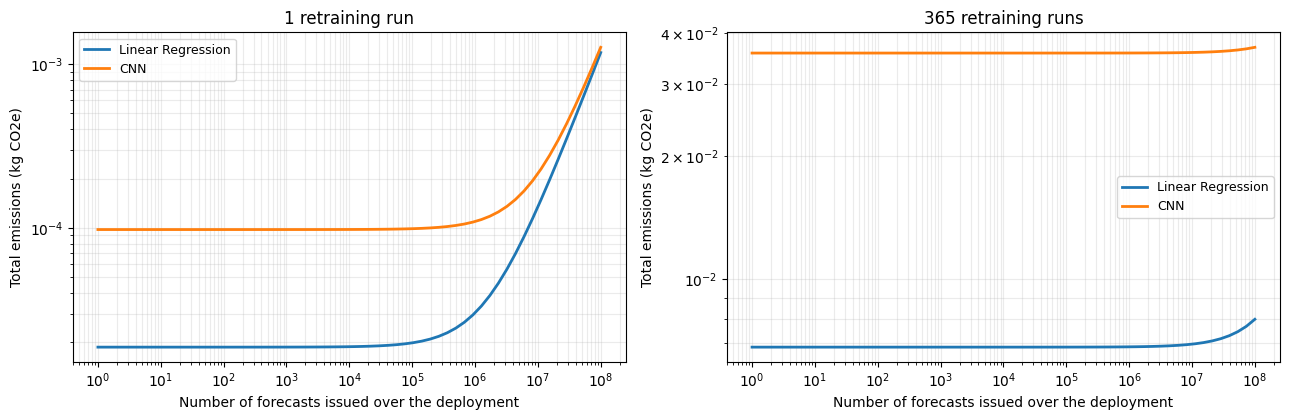

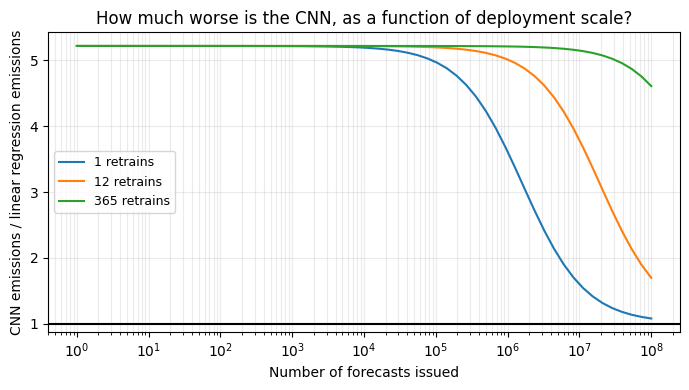


Read the ratio plot, not the absolute one. At the far left, one training run
and almost no forecasts, the ratio is the number the tutorial reports and it is
large. As volume grows, the training difference is diluted and the ratio falls
toward the per-inference ratio, which the notebook itself notes is far less
dramatic. The training-cost argument is therefore an argument about small-scale
research use, not about deployed systems.



In [68]:
# -- Lifecycle emissions: training plus inference plus embodied ---------------
# Everything here comes from measurements already taken in this notebook.
# Per-inference cost is derived from the batch that was actually scored.

n_test_samples = len(X_test)
print(f"Inference runs above scored {n_test_samples} samples.\n")

per_inference = {
    'Linear Regression': lin_reg_inference_emissions / n_test_samples,
    'CNN': cnn_inference_emissions / n_test_samples,
}
per_train = {
    'Linear Regression': baseline_emissions,
    'CNN': cnn_emissions,
}
for name in per_train:
    print(f"{name:20s} train {per_train[name]:.3e} kg   "
          f"per inference {per_inference[name]:.3e} kg")


def lifecycle_kg(name, n_retrain, n_inference):
    return per_train[name] * n_retrain + per_inference[name] * n_inference


# --- Break-even in number of forecasts, at a fixed retrain schedule ----------
# Solve for N where the two lifecycle totals are equal:
#   T_cnn * R + i_cnn * N  =  T_lin * R + i_lin * N
RETRAINS = [1, 12, 365]        # once, monthly for a year, daily for a year

print()
for R in RETRAINS:
    d_train = (per_train['CNN'] - per_train['Linear Regression']) * R
    d_inf = per_inference['CNN'] - per_inference['Linear Regression']
    if d_inf <= 0:
        print(f"retrains={R:4d}: the CNN is cheaper per inference, so its "
              f"training penalty is never repaid by volume alone.")
        continue
    # d_train is the CNN's extra training cost; d_inf is its extra cost per call.
    # The gap only widens with volume, so there is no crossover: the question is
    # instead at what volume inference dominates the comparison.
    n_where_inference_dominates = d_train / d_inf
    print(f"retrains={R:4d}: the CNN's extra training cost equals its extra "
          f"inference cost after {n_where_inference_dominates:,.0f} forecasts.")

# --- The full picture over a plausible deployment ----------------------------
volumes = np.logspace(0, 8, 60)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

for ax, R in zip(axes, [1, 365]):
    for name in per_train:
        ax.plot(volumes, [lifecycle_kg(name, R, v) for v in volumes],
                label=name, lw=2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Number of forecasts issued over the deployment')
    ax.set_ylabel('Total emissions (kg CO2e)')
    ax.set_title(f'{R} retraining run{"s" if R > 1 else ""}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, which='both')

plt.tight_layout()
plt.show()

# --- Ratio, which is the readable version ------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for R in RETRAINS:
    ratio = [lifecycle_kg('CNN', R, v) / lifecycle_kg('Linear Regression', R, v)
             for v in volumes]
    ax.plot(volumes, ratio, label=f'{R} retrains')
ax.axhline(1.0, color='black', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Number of forecasts issued')
ax.set_ylabel('CNN emissions / linear regression emissions')
ax.set_title('How much worse is the CNN, as a function of deployment scale?')
ax.legend(fontsize=9)
ax.grid(alpha=0.25, which='both')
plt.tight_layout()
plt.show()

print("""
Read the ratio plot, not the absolute one. At the far left, one training run
and almost no forecasts, the ratio is the number the tutorial reports and it is
large. As volume grows, the training difference is diluted and the ratio falls
toward the per-inference ratio, which the notebook itself notes is far less
dramatic. The training-cost argument is therefore an argument about small-scale
research use, not about deployed systems.
""")


#### **✍️** What the lifecycle view changes

**The tutorial's headline holds for the case it measured, and only that case.**
"Linear regression is the clear environmental winner" is a statement about one
training run and zero forecasts. That is the research prototype's situation. It
is not the situation of anything in service.

**The training penalty is a fixed cost and fixed costs amortise.** As the number
of forecasts grows, the ratio between the two models converges on the
per-inference ratio, which the notebook already measured and described as much
less dramatic. So the honest statement is conditional: the CNN's carbon
disadvantage is severe for experimentation and shrinks toward the inference
ratio at deployment scale.

**The retraining schedule is the lever nobody discusses.** Compare the panels.
Retraining daily rather than once multiplies the fixed cost by 365 and pushes
the crossover far to the right. Retraining cadence is usually chosen by habit
or by a cron job that someone set years ago, and it is often the single largest
emissions decision in an ML system. Nothing in this notebook, or in most
carbon-tracking practice, surfaces it.

**What is still missing from even this accounting.** Three things, and each
points the same way. Idle capacity: a deployed model occupies hardware between
calls, and that time carries both operational and embodied cost. Data pipeline:
fetching and preprocessing SST fields runs on every forecast and is not
measured anywhere in this notebook. And the marginal grid factor: CodeCarbon
applies an average regional carbon intensity, but the emissions actually caused
by adding load depend on which plant is dispatched at the margin at that hour.
For a decision about *when* to schedule a retraining job, the marginal factor
is the correct one and the average factor can point the wrong way.


<a name="results-and-discussion"></a>

# Results & Discussion

<!--
In this section, describe your results. Briefly describe the performance metrics and cross validation techniques used.
-->

The exercises in this tutorial notebook demonstrated the following lessons related to the tutorial’s learning outcomes:

1. The choice of algorithm has a significant impact on carbon emissions. Training a CNN for ENSO prediction produced approximately 4x the emissions of a simple linear regression model (0.270 g vs. 0.067 g CO2eq), while taking roughly 3.6x longer (\~258s vs. \~70s). This illustrates the diminishing power-law relationship between model complexity and energy consumption, marginal performance gains come at a steep environmental cost.

2. Two practical emission-reduction strategies were tested on the CNN. Reducing model size by removing a fully connected layer cut emissions by 16-18% at the cost of a \~10-12% increase in RMSE. Early stopping was even more effective, reducing emissions by 30-50% with only a minor RMSE increase (~0.03). Both strategies confirm that significant energy savings are achievable with modest trade-offs in model quality.

3. For hyperparameter optimization, the tutorial compared TPE search (via Optuna) with different pruning strategies. Percentile pruning (10th percentile) was the most efficient, producing 0.524 g CO2eq in \~440s, while median pruning was less aggressive, resulting in \~25% higher emissions (0.655 g CO2eq in ~516s). Both found comparably performing hyperparameter sets, but percentile pruning eliminated roughly half the trials early, demonstrating that intelligent trial abandonment is a powerful tool for reducing the cost of hyperparameter search.

4. Beyond operational emissions, the embodied carbon analysis revealed that hardware manufacturing constitutes a non-trivial share of the total footprint, approximately 15% for short training runs (\~27s on a Colab T4) and \~6.7% for extended multi-GPU workloads (48h on 4× A100s). This underscores that hardware selection decisions (GPU type, data center lifespan, platform choice) carry climate consequences that operational tracking alone cannot capture.

5. The tutorial also demonstrated that structured reporting via Model Cards and Datasheets for Datasets provides a concrete mechanism for embedding carbon, water, and provenance metadata into ML documentation, closing the gap between measuring emissions and communicating them transparently to downstream users and stakeholders.

<!--
Finally, include a discussion on the limitations and important takeaways from the exercise. Relate the takeaways back to the user learning outcomes.
-->

### Limitations

<!--
ML algorithms and datasets can reinforce or reflect unfair biases. Reflect on the potential biases in the dataset and/or analysis presented in your tutorial, including its potential societal impact, and discuss how you might go about addressing this challenge.

Additionally, we encourage authors to highlight and reflect upon any data gaps that may be present along with suggested pathways to overcome these gaps as well as steps for further development and usage. To assist with identifying the types of data gaps that could exist please see CCAI's [data gaps taxonomy](https://www.climatechange.ai/dev/datagaps/info#taxonomy-of-data-gaps).
-->

#### Limitations of Operational Emission Tracking

Computing operational carbon emissions introduces significant real-world inaccuracies, primarily due to grid-intensity volatility and data center configuration blind spots. Open-source tracking tools like CodeCarbon estimate carbon generation by multiplying a server’s measured energy consumption by a regional carbon intensity factor. However, these grid factors are usually static, historical averages rather than live, real-time measurements, completely ignoring hourly shifts in renewable energy availability. Additionally, these software trackers can only measure the direct power consumption of local processing chips (CPUs and GPUs); they have zero native visibility into a facility's true Power Usage Effectiveness (PUE). They cannot automatically account for the massive secondary electrical loads required for structural cooling, data center networking, and electrical grid line losses, which often leaves a large portion of the true operational footprint unmeasured.

#### Limitations of the Amortization Method

While time-based amortization for computing embodied carbon emissions aligns with the methodologies used in prominent Green AI literature such as Luccioni et al. (2023) [12], it relies heavily on generalized proxy data and unverified assumptions. Because major cloud providers and hardware manufacturers closely guard their supply chain metrics as proprietary secrets, researchers are forced to use static lifecycle estimates from disconnected third-party reports. Furthermore, this calculation assumes that a server draws a uniform, linear allocation of manufacturing debt over its lifespan, completely ignoring variables like varying hardware degradation rates, the custom hardware modifications made by cloud data centers, and the carbon overhead of unused, idle standby hardware. Consequently, this approach provides a useful educational estimation rather than an exact, scientifically reproducible measurement of real-world environmental impact.

#### Limitations of Reporting Frameworks

Model Cards and Datasheets for Datasets provide structured
transparency, but the exercises in this tutorial require manual
metadata entry. The pipeline from CodeCarbon's emissions.csv
output to a complete model card YAML block is not automated,
creating a gap between measurement and reporting that could
introduce transcription errors or incomplete documentation in
practice.

#### Limitations of Inference Emission Tracking

The inference emissions measured in this tutorial are captured
within the Colab notebook environment and do not reflect true
production deployment conditions. Real-world inference emissions
depend heavily on serving infrastructure (batch size, request
throughput, GPU utilization, and whether the model runs on
dedicated or shared hardware), none of which are captured in
a local notebook experiment.

## Next Steps

<!--
*   What do you imagine would be the next steps for your readers after finishing your tutorial?
*   Discuss other potential climate-related applications for the method or tool discussed in the tutorial.
*   Do you know of other climate-related datasets similar to the one used in this tutorial? List them here.
-->

After completing this tutorial, readers should be able to:

*   **Identify sources of carbon emissions.** Recognize that ML carbon footprints span operational emissions and embodied emissions, and that both must be accounted for in any honest assessment.

*   **Reduce operational emissions without large performance sacrifices.** Apply practical strategies such as choosing simpler algorithms when appropriate, using early stopping, reducing model size, and employing pruned hyperparameter search to cut emissions with only modest accuracy trade-offs.

*   **Select hardware thoughtfully.** Compare GPUs and compute platforms not just by speed and cost but by their embodied carbon footprint, expected lifespan, and the carbon intensity of the hosting data center's energy grid.

*   **Track and report emissions transparently.** Use tools like CodeCarbon to measure emissions during training and inference, and document results in structured formats such as Model Cards and Datasheets for Datasets, including carbon, water, and provenance metadata.

*   **Explore geographic optimization.** If you have access to cloud providers (AWS, GCP, Azure), compare emissions across compute regions to find grids with lower carbon intensity. Tools like [Electricity Maps](https://app.electricitymap.org) can help identify low-intensity regions in real time.

*   **Consider water impact.** Investigate the Water Usage Effectiveness (WUE) of your compute infrastructure using resources like the [WRI Aqueduct Water Risk Atlas](https://www.wri.org/applications/aqueduct/water-risk-atlas/), particularly when training in water-stressed regions.

*   **Contribute to Green AI tooling.** Projects like [CodeCarbon](https://github.com/mlco2/codecarbon), [carbontracker](https://github.com/lfwa/carbontracker), and [eco2ai](https://github.com/sb-ai-lab/Eco2AI) are actively maintained and welcome contributions to improve tracking accuracy and expand hardware support.

### Other Potential Climate-Related Applications

The methods introduced in this tutorial can be extended to a wide range of climate-related use cases, including:

*   **Apply these methods to other climate-relevant tasks.** The CodeCarbon tracking and emission-reduction strategies demonstrated here transfer directly to workloads such as weather forecasting (e.g., Pangu-Weather, GraphCast), renewable energy output prediction, satellite-based deforestation monitoring, and climate model emulation. All of these involve training and deploying ML models whose carbon footprints can be measured and minimized using the same pipeline.

*   **Try similar climate datasets.** The SST-based ENSO forecasting task in this tutorial uses relatively small, low-resolution data. For larger-scale experiments that stress-test emission tracking at higher compute budgets, consider datasets such as ERA5 reanalysis (ECMWF), CMIP6 climate model outputs, NASA MERRA-2, or the [ClimateBench](https://github.com/microsoft/climatebench) benchmark — all of which support climate-relevant ML tasks with varying data complexity and compute demands.

# References

<!-- [1] Kaack, L.H., Donti, P.L., Strubell, E. et al. "Aligning artificial intelligence with climate change mitigation." Nat. Clim. Chang. 12, 518–527 (2022). https://doi.org/10.1038/s41558-022-01377-7 -->

[1]\. Kaack, L.H., Donti, P.L., Strubell, E. et al. (2022). Aligning artificial intelligence with climate change mitigation. *Nature Climate Change*, 12, 518–527. [https://doi.org/10.1038/s41558-022-01377-7](https://doi.org/10.1038/s41558-022-01377-7)

<!-- [2] Oil in the Cloud: How Tech Companies are Helping Big Oil Profit from Climate Destruction (Greenpeace, 2019); https://www.greenpeace.org/usa/reports/oil-in-the-cloud/ -->

[2]\. Oil in the Cloud: How Tech Companies are Helping Big Oil Profit from Climate Destruction. Greenpeace (2019). [https://www.greenpeace.org/usa/reports/oil-in-the-cloud/](https://www.greenpeace.org/usa/reports/oil-in-the-cloud/)

<!-- [3] AI-Based Smart Farming: The Rise of Machine Learning in Livestock Farming (Nexocode, 2022); https://nexocode.com/blog/posts/ai-based-smart-farming-machine-learning-in-livestock-farming/ -->

[3]\. AI-Based Smart Farming: The Rise of Machine Learning in Livestock Farming. Nexocode (2022). [https://nexocode.com/blog/posts/ai-based-smart-farming-machine-learning-in-livestock-farming/](https://nexocode.com/blog/posts/ai-based-smart-farming-machine-learning-in-livestock-farming/)

<!-- [4]  Dario Amodei and Daniel Hernandez. 2018. AI and Compute. https://openai.com/blog/ai-and-compute/ -->

[4]\. Amodei, D. & Hernandez, D. (2018). AI and Compute. OpenAI. [https://openai.com/blog/ai-and-compute/](https://openai.com/blog/ai-and-compute/)

<!-- [5] Patterson, David A. et al. “The Carbon Footprint of Machine Learning Training Will Plateau, Then Shrink.” Computer 55 (2022): 18-28. -->

[5]\. Patterson, D.A. et al. (2022). The carbon footprint of machine learning training will plateau, then shrink. *Computer*, 55, 18–28.

<!-- [6] Budennyy, Semen A. et al. “eco2AI: Carbon Emissions Tracking of Machine Learning Models as the First Step Towards Sustainable AI.” Doklady Mathematics 106 (2022): S118 - S128. -->

[6]\. Budennyy, S.A. et al. (2022). eco2AI: Carbon emissions tracking of machine learning models as the first step towards sustainable AI. *Doklady Mathematics*, 106, S118–S128.

<!-- [7] Wu, Carole-Jean et al. "Sustainable AI: Environmental Implications, Challenges and Opportunities." Proceedings of the 5th MLSys Conference, Santa Clara, CA, USA, 2022. -->

[7]\. Wu, C.-J. et al. (2022). Sustainable AI: Environmental implications, challenges and opportunities. *Proceedings of the 5th MLSys Conference*, Santa Clara, CA, USA.

<!-- [8] Jiang, A. H. et al. Accelerating deep learning by focusing on the biggest losers. Preprint at https://arxiv.org/abs/1910.00762 (2019) -->

[8]\. Jiang, A.H. et al. (2019). Accelerating deep learning by focusing on the biggest losers. *arXiv preprint*. [https://arxiv.org/abs/1910.00762](https://arxiv.org/abs/1910.00762)

<!-- [9] ChatGPT reaches 100 million users two months after launch (The Guardian, 2023); https://www.theguardian.com/technology/2023/feb/02/chatgpt-100-million-users-open-ai-fastest-growing-app -->

[9]\. ChatGPT reaches 100 million users two months after launch. *The Guardian* (2023). [https://www.theguardian.com/technology/2023/feb/02/chatgpt-100-million-users-open-ai-fastest-growing-app](https://www.theguardian.com/technology/2023/feb/02/chatgpt-100-million-users-open-ai-fastest-growing-app)

<!-- [10] How much electricity does an American home use? (U.S. Energy Information Administration, 2022); https://www.eia.gov/tools/faqs/faq.php?id=97&t=3# -->

[10]\. How much electricity does an American home use? U.S. Energy Information Administration (2022). [https://www.eia.gov/tools/faqs/faq.php?id=97&t=3](https://www.eia.gov/tools/faqs/faq.php?id=97&t=3)

<!-- [11] Lannelongue, L., Grealey, J., Inouye, M. "Green Algorithms: Quantifying the carbon footprint of computation." Advanced Science 8(12), 2021. https://doi.org/10.1002/advs.202100707 -->

[11]\. Lannelongue, L., Grealey, J., & Inouye, M. (2021). Green algorithms: Quantifying the carbon footprint of computation. *Advanced Science*, 8(12). [https://doi.org/10.1002/advs.202100707](https://doi.org/10.1002/advs.202100707)

<!-- [12] Luccioni, A. S., Viguier, S., Ligozat, A.-L. (2023). Estimating the Carbon Footprint of BLOOM, a 176B Parameter Language Model. Journal of Machine Learning Research, 24(253), 1–15. http://jmlr.org/papers/v24/23-0069.html -->

[12]\. Luccioni, A.S., Viguier, S., & Ligozat, A.-L. (2023). Estimating the carbon footprint of BLOOM, a 176B parameter language model. *Journal of Machine Learning Research*, 24(253), 1–15. [http://jmlr.org/papers/v24/23-0069.html](http://jmlr.org/papers/v24/23-0069.html)

<!-- [13] Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2019). Model Cards for Model Reporting. Proceedings of the Conference on Fairness, Accountability, and Transparency, 220–229. https://doi.org/10.1145/3287560.3287596 -->

[13]\. Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I.D., & Gebru, T. (2019). Model cards for model reporting. *Proceedings of the Conference on Fairness, Accountability, and Transparency*, 220–229. [https://doi.org/10.1145/3287560.3287596](https://doi.org/10.1145/3287560.3287596)

<!-- [14] Jouneaux, G., & Cabot, J. (2025). Towards Sustainability Model Cards. arXiv. https://doi.org/10.48550/arXiv.2507.19559 -->

[14]\. Jouneaux, G. & Cabot, J. (2025). Towards sustainability model cards. *arXiv*. [https://doi.org/10.48550/arXiv.2507.19559](https://doi.org/10.48550/arXiv.2507.19559)

<!-- [15] Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J. W., Wallach, H., Daumé III, H., & Crawford, K. (2021). Datasheets for Datasets. Communications of the ACM, 64(12), 86–92. https://doi.org/10.1145/3458723 -->

[15]\. Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J.W., Wallach, H., Daumé III, H., & Crawford, K. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86–92. [https://doi.org/10.1145/3458723](https://doi.org/10.1145/3458723)

[16]\. Freitag, C., Berners-Lee, M., Widdicks, K., Knowles, B., Blair, G. S., & Friday, A. (2021). The real climate and transformative impact of ICT: A critique of estimates, trends, and regulations. *Patterns, Elsevier*, 2(9). [https://doi.org/10.1016/j.patter.2021.100340](https://doi.org/10.1016/j.patter.2021.100340)

[17]\. Li, P., Yang J., Islam M.A., & Ren S. (2025). Making AI Less "Thirsty": Uncovering and Addressing the Secret Water Footprint of AI Models. *Communications of the ACM*, 68(7), 54–61. [https://doi.org/10.1145/3724499](https://doi.org/10.1145/3724499)